In [ ]:
# ============================================================
# TFM – Modelado de Datos (EDA)
# Dataset Poses baokhang9826_YOLO
# ============================================================
# Antes de ejecutar este notebook:
#   Runtime → Change runtime type → GPU (T4 / A100) + High-RAM
# ============================================================

In [1]:
# ============================================================
# CELDA 1 – Montar Drive y verificar GPU
# ============================================================
import os
import sys
import subprocess
import shutil
import torch
from google.colab import drive

# --- Montar Drive limpiando si es necesario ---
mountpoint = "/content/drive"

if os.path.ismount(mountpoint):
    print("ℹ️  Google Drive ya estaba montado, continuando...")
else:
    # Limpiar directorio sucio si tiene archivos residuales
    if os.path.isdir(mountpoint) and os.listdir(mountpoint):
        shutil.rmtree(mountpoint)
        os.makedirs(mountpoint)
        print("🧹 Directorio limpiado.")
    drive.mount(mountpoint, force_remount=True)
    print("✅ Google Drive montado correctamente.")

# --- Verificación de hardware ---
print("=" * 70)
print("🖥️  VERIFICACIÓN DE HARDWARE")
print("=" * 70)
print(f"🐍 Python : {sys.version.split()[0]}")
print(f"🔥 PyTorch: {torch.__version__}")

if torch.cuda.is_available():
    print(f"✅ CUDA disponible")
    print(f"🎯 GPU     : {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  CUDA no disponible. Activa GPU en Runtime → Change runtime type → GPU.")

try:
    gpu_info = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
    if gpu_info.returncode == 0:
        print(gpu_info.stdout)
    else:
        print("⚠️  nvidia-smi no retornó información.")
except Exception as e:
    print(f"❌ No se pudo ejecutar nvidia-smi: {e}")

ℹ️  Google Drive ya estaba montado, continuando...
🖥️  VERIFICACIÓN DE HARDWARE
🐍 Python : 3.12.13
🔥 PyTorch: 2.11.0+cu128
✅ CUDA disponible
🎯 GPU     : Tesla T4
Wed Jun 17 06:42:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             15W /   70W |       3MiB /  15360MiB |  

In [ ]:
# ============================================================
# CELDA 2 – Instalar Ultralytics YOLO
# ============================================================

!pip install -q ultralytics

import ultralytics
from ultralytics import YOLO

ultralytics.checks()

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (8 CPUs, 51.0 GB RAM, 47.1/235.7 GB disk)


In [ ]:
# ============================================================
# CELDA 3 – Rutas del dataset limpio
# ============================================================

from pathlib import Path
import yaml

YOLO_DATASET = Path("/content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15_CLEAN")
DATA_YAML = YOLO_DATASET / "data.yaml"

print("=" * 70)
print("📁 DATASET PARA ENTRENAMIENTO")
print("=" * 70)

print(f"Dataset : {YOLO_DATASET}")
print(f"YAML    : {DATA_YAML}")
print(f"Existe dataset?: {YOLO_DATASET.exists()}")
print(f"Existe YAML?   : {DATA_YAML.exists()}")

with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_yaml = yaml.safe_load(f)

print("\nContenido data.yaml:")
for k, v in data_yaml.items():
    print(f"{k}: {v}")

print("\nVerificación de carpetas:")
for split in ["train", "val", "test"]:
    print(f"{split.upper()}")
    print(" images:", (YOLO_DATASET / "images" / split).exists())
    print(" labels:", (YOLO_DATASET / "labels" / split).exists())

📁 DATASET PARA ENTRENAMIENTO
Dataset : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15_CLEAN
YAML    : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15_CLEAN/data.yaml
Existe dataset?: True
Existe YAML?   : True

Contenido data.yaml:
path: /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15_CLEAN
train: images/train
val: images/val
test: images/test
nc: 2
names: ['fall', 'non_fall']

Verificación de carpetas:
TRAIN
 images: True
 labels: True
VAL
 images: True
 labels: True
TEST
 images: True
 labels: True


In [ ]:
# ============================================================
# CELDA 4 – Entrenamiento base YOLO
# ============================================================

from ultralytics import YOLO
from pathlib import Path

# Modelo base recomendado para iniciar
# yolov8n.pt = liviano y rápido
# yolov8s.pt = mejor capacidad, más lento
MODEL_NAME = "yolov8n.pt"

model = YOLO(MODEL_NAME)

PROJECT_DIR = "/content/drive/MyDrive/TFM/runs_yolo_caidas"
RUN_NAME = "baseline_yolov8n_clean_70_15_15"

results = model.train(
    data=str(DATA_YAML),
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,
    project=PROJECT_DIR,
    name=RUN_NAME,
    exist_ok=True,
    device=0,
    workers=2
)

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15_CLEAN/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_yolov8n_clean_70_15_15, nbs=64, nms=False, 

In [ ]:
# ============================================================
# CELDA 4B – Comprobar cantidad de imágenes y labels en train y val
# ============================================================

from pathlib import Path
import pandas as pd

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

splits_a_revisar = ["train", "val"]

filas = []

for split in splits_a_revisar:
    img_dir = YOLO_DATASET / "images" / split
    lbl_dir = YOLO_DATASET / "labels" / split

    imgs = sorted([
        p for p in img_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMG_EXTS
    ]) if img_dir.exists() else []

    lbls = sorted([
        p for p in lbl_dir.iterdir()
        if p.is_file() and p.suffix.lower() == ".txt"
    ]) if lbl_dir.exists() else []

    img_stems = {p.stem for p in imgs}
    lbl_stems = {p.stem for p in lbls}

    filas.append({
        "split": split,
        "ruta_imagenes": str(img_dir),
        "ruta_labels": str(lbl_dir),
        "existe_images": img_dir.exists(),
        "existe_labels": lbl_dir.exists(),
        "cantidad_imagenes": len(imgs),
        "cantidad_labels": len(lbls),
        "imagenes_sin_label": len(img_stems - lbl_stems),
        "labels_sin_imagen": len(lbl_stems - img_stems)
    })

df_train_val = pd.DataFrame(filas)

print("=" * 70)
print("📋 COMPROBACIÓN DE TRAIN Y VAL")
print("=" * 70)

display(df_train_val)

📋 COMPROBACIÓN DE TRAIN Y VAL


,split,ruta_imagenes,ruta_labels,existe_images,existe_labels,cantidad_imagenes,cantidad_labels,imagenes_sin_label,labels_sin_imagen
0,train,/content/drive/MyDrive/TFM/datasets/baokhang98...,/content/drive/MyDrive/TFM/datasets/baokhang98...,True,True,4940,4940,0,0
1,val,/content/drive/MyDrive/TFM/datasets/baokhang98...,/content/drive/MyDrive/TFM/datasets/baokhang98...,True,True,900,900,0,0


In [ ]:
# ============================================================
# CELDA 5 – Definir rutas para evaluación del modelo entrenado
# ============================================================

from pathlib import Path

TFM_DIR = Path("/content/drive/MyDrive/TFM")

YOLO_DATASET = TFM_DIR / "datasets" / "baokhang9826_YOLO" / "YOLO_70_15_15_CLEAN"
DATA_YAML = YOLO_DATASET / "data.yaml"

PROJECT_DIR = TFM_DIR / "runs_yolo_caidas"
RUN_NAME = "baseline_yolov8n_clean_70_15_15"

BEST_MODEL = PROJECT_DIR / RUN_NAME / "weights" / "best.pt"
LAST_MODEL = PROJECT_DIR / RUN_NAME / "weights" / "last.pt"

print("=" * 70)
print("📁 RUTAS PARA EVALUACIÓN")
print("=" * 70)

print(f"📁 Dataset    : {YOLO_DATASET}")
print(f"📄 data.yaml  : {DATA_YAML}")
print(f"🏆 best.pt    : {BEST_MODEL}")
print(f"📦 last.pt    : {LAST_MODEL}")

print("\nVerificación:")
print(f"Existe dataset?: {YOLO_DATASET.exists()}")
print(f"Existe YAML?   : {DATA_YAML.exists()}")
print(f"Existe best.pt?: {BEST_MODEL.exists()}")
print(f"Existe last.pt?: {LAST_MODEL.exists()}")

if not DATA_YAML.exists():
    raise FileNotFoundError(f"No se encontró DATA_YAML:\n{DATA_YAML}")

if not BEST_MODEL.exists():
    raise FileNotFoundError(f"No se encontró BEST_MODEL:\n{BEST_MODEL}")

📁 RUTAS PARA EVALUACIÓN
📁 Dataset    : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15_CLEAN
📄 data.yaml  : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15_CLEAN/data.yaml
🏆 best.pt    : /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15/weights/best.pt
📦 last.pt    : /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15/weights/last.pt

Verificación:
Existe dataset?: True
Existe YAML?   : True
Existe best.pt?: True
Existe last.pt?: True


In [ ]:
# ============================================================
# CELDA 6 – Evaluación final en TEST
# ============================================================

from ultralytics import YOLO

# Cargar el mejor modelo entrenado
model_best = YOLO(str(BEST_MODEL))

print("=" * 70)
print("🧪 EVALUACIÓN FINAL EN TEST")
print("=" * 70)

print(f"🏆 Modelo     : {BEST_MODEL}")
print(f"📄 data.yaml  : {DATA_YAML}")
print(f"📁 Dataset    : {YOLO_DATASET}")

metrics_test = model_best.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    plots=True,
    project=str(PROJECT_DIR),
    name=f"{RUN_NAME}_test_eval",
    exist_ok=True
)

print("\n" + "=" * 70)
print("✅ EVALUACIÓN TEST FINALIZADA")
print("=" * 70)

print(metrics_test)

print("\n📁 Resultados guardados en:")
print(PROJECT_DIR / f"{RUN_NAME}_test_eval")

🧪 EVALUACIÓN FINAL EN TEST
🏆 Modelo     : /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15/weights/best.pt
📄 data.yaml  : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15_CLEAN/data.yaml
📁 Dataset    : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15_CLEAN
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.4 ms, read: 0.1±0.0 MB/s, size: 25.3 KB)
val: Scanning /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15_CLEAN/labels/test... 896 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 896/896 34.1it/s 26.3s
val: New cache created: /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15_CLEAN/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 7.2it/s 7.8s
           

El modelo YOLOv8n entrenado sobre el dataset limpio YOLO_70_15_15_CLEAN obtuvo en el conjunto de prueba una precisión global de 0.991, recall de 0.981, mAP50 de 0.994 y mAP50-95 de 0.982. Para la clase fall, el modelo alcanzó una precisión de 0.983 y un recall de 0.982, mientras que para non_fall obtuvo una precisión de 1.000 y recall de 0.981.

In [ ]:
# ============================================================
# CELDA 7 – Guardar resumen limpio de métricas TEST
# ============================================================

from pathlib import Path
import pandas as pd

RESULTS_DIR = PROJECT_DIR / f"{RUN_NAME}_test_eval"

metricas_resumen = {
    "split": "test",
    "images": 896,
    "instances": 903,
    "precision_all": 0.991,
    "recall_all": 0.981,
    "mAP50_all": 0.994,
    "mAP50_95_all": 0.982,
    "precision_fall": 0.983,
    "recall_fall": 0.982,
    "mAP50_fall": 0.994,
    "mAP50_95_fall": 0.979,
    "precision_non_fall": 1.000,
    "recall_non_fall": 0.981,
    "mAP50_non_fall": 0.995,
    "mAP50_95_non_fall": 0.985,
}

df_metricas_test = pd.DataFrame([metricas_resumen])

OUT_CSV = RESULTS_DIR / "metricas_test_resumen.csv"
OUT_TXT = RESULTS_DIR / "metricas_test_resumen.txt"

df_metricas_test.to_csv(OUT_CSV, index=False)

with open(OUT_TXT, "w", encoding="utf-8") as f:
    f.write("Resumen métricas TEST - YOLOv8n\n")
    f.write("=" * 50 + "\n")
    for k, v in metricas_resumen.items():
        f.write(f"{k}: {v}\n")

print("✅ Resumen de métricas guardado en:")
print(OUT_CSV)
print(OUT_TXT)

display(df_metricas_test)

✅ Resumen de métricas guardado en:
/content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15_test_eval/metricas_test_resumen.csv
/content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15_test_eval/metricas_test_resumen.txt


,split,images,instances,precision_all,recall_all,mAP50_all,mAP50_95_all,precision_fall,recall_fall,mAP50_fall,mAP50_95_fall,precision_non_fall,recall_non_fall,mAP50_non_fall,mAP50_95_non_fall
0,test,896,903,0.991,0.981,0.994,0.982,0.983,0.982,0.994,0.979,1.0,0.981,0.995,0.985


In [ ]:
# ============================================================
# CELDA 8 – Inferencia visual sobre imágenes de TEST
# ============================================================

from pathlib import Path
import random
from ultralytics import YOLO

model_best = YOLO(str(BEST_MODEL))

test_img_dir = YOLO_DATASET / "images" / "test"

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

imgs_test = [
    p for p in test_img_dir.iterdir()
    if p.is_file() and p.suffix.lower() in IMG_EXTS
]

print(f"Imágenes TEST encontradas: {len(imgs_test):,}")

random.seed(42)
muestras = random.sample(imgs_test, min(30, len(imgs_test)))

PRED_PROJECT = TFM_DIR / "predicciones_yolo_caidas"
PRED_NAME = "test_visual_baseline_yolov8n"

pred_results = model_best.predict(
    source=[str(p) for p in muestras],
    imgsz=640,
    conf=0.25,
    save=True,
    save_txt=True,
    save_conf=True,
    project=str(PRED_PROJECT),
    name=PRED_NAME,
    exist_ok=True
)

print("\n✅ Predicciones visuales guardadas en:")
print(PRED_PROJECT / PRED_NAME)

Imágenes TEST encontradas: 896

0: 480x640 1 non_fall, 3.3ms
1: 480x640 1 fall, 3.3ms
2: 480x640 1 non_fall, 3.3ms
3: 480x640 1 fall, 3.3ms
4: 480x640 1 fall, 3.3ms
5: 480x640 1 fall, 3.3ms
6: 480x640 1 fall, 3.3ms
7: 480x640 1 fall, 3.3ms
8: 480x640 1 fall, 3.3ms
9: 480x640 1 fall, 3.3ms
10: 480x640 1 non_fall, 3.3ms
11: 480x640 1 non_fall, 3.3ms
12: 480x640 1 non_fall, 3.3ms
13: 480x640 1 non_fall, 3.3ms
14: 480x640 1 non_fall, 3.3ms
15: 480x640 1 non_fall, 3.3ms
16: 480x640 1 fall, 3.3ms
17: 480x640 1 fall, 3.3ms
18: 480x640 1 fall, 3.3ms
19: 480x640 1 fall, 3.3ms
20: 480x640 1 fall, 3.3ms
21: 480x640 1 non_fall, 3.3ms
22: 480x640 1 non_fall, 3.3ms
23: 480x640 1 fall, 3.3ms
24: 480x640 1 non_fall, 3.3ms
25: 480x640 1 fall, 3.3ms
26: 480x640 1 fall, 3.3ms
27: 480x640 1 non_fall, 3.3ms
28: 480x640 1 non_fall, 3.3ms
29: 480x640 1 non_fall, 3.3ms
Speed: 2.3ms preprocess, 3.3ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/drive/MyDrive/TFM/pr

Imágenes TEST encontradas: 896
Se tomaron 30 imágenes de muestra
En las 30 imágenes el modelo detectó 1 objeto
Las predicciones se guardaron correctamente

🖼️ VISUALIZACIÓN DE PREDICCIONES
📁 Carpeta de predicciones: /content/drive/MyDrive/TFM/predicciones_yolo_caidas/test_visual_baseline_yolov8n
¿Existe?: True
Predicciones encontradas: 30


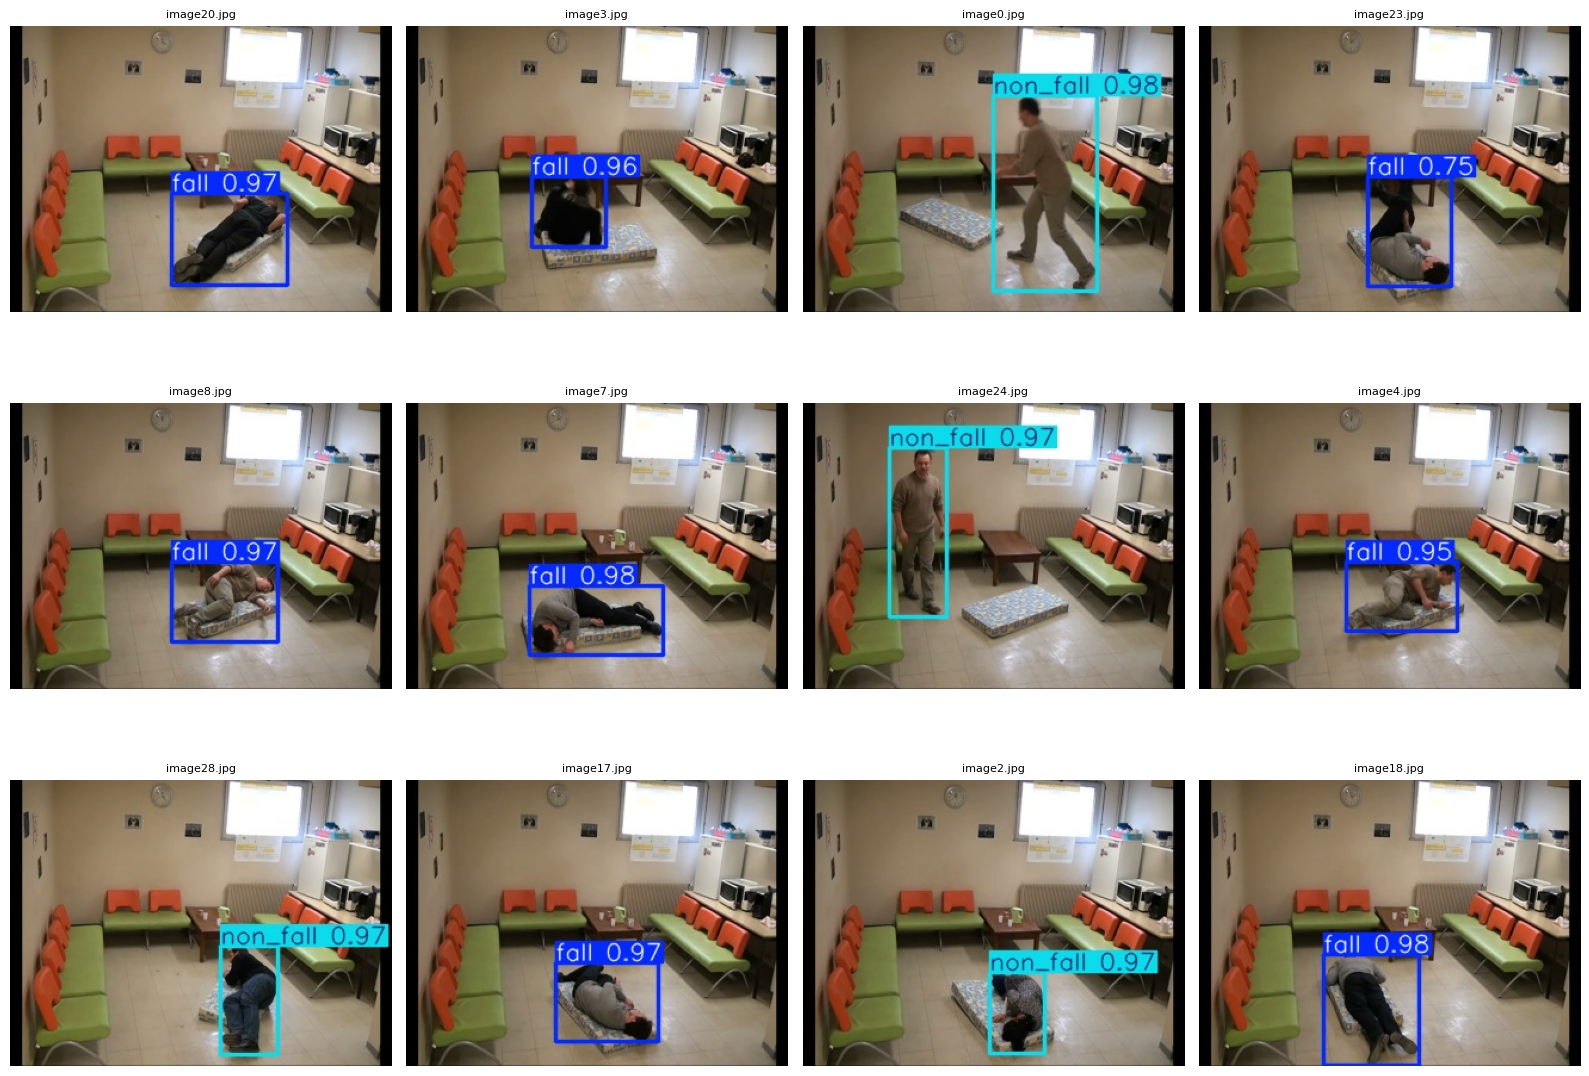

In [ ]:
# ============================================================
# CELDA 9 – Mostrar predicciones visuales guardadas
# ============================================================

from pathlib import Path
import random
import math
import cv2
import matplotlib.pyplot as plt

PRED_DIR = Path("/content/drive/MyDrive/TFM/predicciones_yolo_caidas/test_visual_baseline_yolov8n")

print("=" * 70)
print("🖼️ VISUALIZACIÓN DE PREDICCIONES")
print("=" * 70)

print(f"📁 Carpeta de predicciones: {PRED_DIR}")
print(f"¿Existe?: {PRED_DIR.exists()}")

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

pred_imgs = [
    p for p in PRED_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMG_EXTS
]

print(f"Predicciones encontradas: {len(pred_imgs):,}")

if len(pred_imgs) == 0:
    raise RuntimeError("No se encontraron imágenes de predicción para mostrar.")

random.seed(42)
muestras = random.sample(pred_imgs, min(12, len(pred_imgs)))

cols = 4
rows = math.ceil(len(muestras) / cols)

plt.figure(figsize=(16, 4 * rows))

for i, img_path in enumerate(muestras, start=1):
    img = cv2.imread(str(img_path))

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.title(img_path.name, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELDA 10 – Comparar predicción vs etiqueta real en muestras
# ============================================================

from pathlib import Path
import pandas as pd

YOLO_DATASET = Path("/content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15_CLEAN")
GT_LABEL_DIR = YOLO_DATASET / "labels" / "test"

PRED_DIR = Path("/content/drive/MyDrive/TFM/predicciones_yolo_caidas/test_visual_baseline_yolov8n")
PRED_LABEL_DIR = PRED_DIR / "labels"

CLASS_NAMES = ["fall", "non_fall"]

print("=" * 70)
print("🔎 COMPARACIÓN PREDICCIÓN VS ETIQUETA REAL")
print("=" * 70)

print(f"📁 GT labels   : {GT_LABEL_DIR}")
print(f"📁 Pred labels : {PRED_LABEL_DIR}")

def leer_gt_label(path):
    """
    Lee label real YOLO:
      class_id cx cy w h
    """
    if not path.exists() or path.stat().st_size == 0:
        return None

    clases = []

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.strip().split()

            if len(parts) >= 5:
                try:
                    clases.append(int(float(parts[0])))
                except Exception:
                    pass

    if not clases:
        return None

    # Si hay varias cajas, toma la clase más frecuente
    return max(set(clases), key=clases.count)


def leer_pred_label(path):
    """
    Lee predicción YOLO guardada con save_conf=True:
      class_id cx cy w h conf
    """
    if not path.exists() or path.stat().st_size == 0:
        return None, None

    preds = []

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.strip().split()

            if len(parts) >= 6:
                try:
                    class_id = int(float(parts[0]))
                    conf = float(parts[5])
                    preds.append((class_id, conf))
                except Exception:
                    pass

    if not preds:
        return None, None

    # Tomar la predicción con mayor confianza
    pred = max(preds, key=lambda x: x[1])

    return pred[0], pred[1]


pred_label_files = sorted([
    p for p in PRED_LABEL_DIR.iterdir()
    if p.is_file() and p.suffix.lower() == ".txt"
])

filas = []

for pred_path in pred_label_files:
    stem = pred_path.stem

    gt_path = GT_LABEL_DIR / f"{stem}.txt"

    gt_cls = leer_gt_label(gt_path)
    pred_cls, conf = leer_pred_label(pred_path)

    gt_name = CLASS_NAMES[gt_cls] if gt_cls is not None and 0 <= gt_cls < len(CLASS_NAMES) else "SIN_GT"
    pred_name = CLASS_NAMES[pred_cls] if pred_cls is not None and 0 <= pred_cls < len(CLASS_NAMES) else "SIN_PRED"

    correcto = gt_cls == pred_cls

    filas.append({
        "imagen": stem,
        "gt_class_id": gt_cls,
        "gt_class": gt_name,
        "pred_class_id": pred_cls,
        "pred_class": pred_name,
        "confidence": conf,
        "correcto": correcto
    })

df_comparacion = pd.DataFrame(filas)

print("\n📋 Comparación:")
display(df_comparacion)

if len(df_comparacion) > 0:
    acc_muestra = df_comparacion["correcto"].mean() * 100
    print(f"\n✅ Exactitud en estas muestras: {acc_muestra:.2f}%")

    errores = df_comparacion[df_comparacion["correcto"] == False]

    if len(errores) > 0:
        print("\n⚠️ Errores encontrados:")
        display(errores)
    else:
        print("\n✅ No se encontraron errores en estas predicciones guardadas.")

🔎 COMPARACIÓN PREDICCIÓN VS ETIQUETA REAL
📁 GT labels   : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15_CLEAN/labels/test
📁 Pred labels : /content/drive/MyDrive/TFM/predicciones_yolo_caidas/test_visual_baseline_yolov8n/labels

📋 Comparación:


,imagen,gt_class_id,gt_class,pred_class_id,pred_class,confidence,correcto
0,image0,None,SIN_GT,1,non_fall,0.980721,False
1,image1,None,SIN_GT,0,fall,0.980201,False
2,image10,None,SIN_GT,1,non_fall,0.962116,False
3,image11,None,SIN_GT,1,non_fall,0.947630,False
4,image12,None,SIN_GT,1,non_fall,0.973624,False
5,image13,None,SIN_GT,1,non_fall,0.976603,False
6,image14,None,SIN_GT,1,non_fall,0.967449,False
7,image15,None,SIN_GT,1,non_fall,0.973614,False
8,image16,None,SIN_GT,0,fall,0.970058,False
9,image17,None,SIN_GT,0,fall,0.971802,False



✅ Exactitud en estas muestras: 0.00%

⚠️ Errores encontrados:


,imagen,gt_class_id,gt_class,pred_class_id,pred_class,confidence,correcto
0,image0,None,SIN_GT,1,non_fall,0.980721,False
1,image1,None,SIN_GT,0,fall,0.980201,False
2,image10,None,SIN_GT,1,non_fall,0.962116,False
3,image11,None,SIN_GT,1,non_fall,0.947630,False
4,image12,None,SIN_GT,1,non_fall,0.973624,False
5,image13,None,SIN_GT,1,non_fall,0.976603,False
6,image14,None,SIN_GT,1,non_fall,0.967449,False
7,image15,None,SIN_GT,1,non_fall,0.973614,False
8,image16,None,SIN_GT,0,fall,0.970058,False
9,image17,None,SIN_GT,0,fall,0.971802,False


In [ ]:
# ============================================================
# CELDA 10 – Inferencia visual conservando nombres originales
#            y comparación correcta con Ground Truth
# ============================================================

from pathlib import Path
import random
import shutil
import pandas as pd
from ultralytics import YOLO

# ------------------------------------------------------------
# 1. Rutas base
# ------------------------------------------------------------

TFM_DIR = Path("/content/drive/MyDrive/TFM")

YOLO_DATASET = TFM_DIR / "datasets" / "baokhang9826_YOLO" / "YOLO_70_15_15_CLEAN"
DATA_YAML = YOLO_DATASET / "data.yaml"

PROJECT_DIR = TFM_DIR / "runs_yolo_caidas"
RUN_NAME = "baseline_yolov8n_clean_70_15_15"

BEST_MODEL = PROJECT_DIR / RUN_NAME / "weights" / "best.pt"

test_img_dir = YOLO_DATASET / "images" / "test"
test_lbl_dir = YOLO_DATASET / "labels" / "test"

CLASS_NAMES = ["fall", "non_fall"]
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Carpeta temporal para la muestra
SAMPLE_DIR = TFM_DIR / "muestras_test_yolo_caidas" / "imagenes_test_muestra"

# Carpeta donde se guardarán las predicciones
PRED_PROJECT = TFM_DIR / "predicciones_yolo_caidas"
PRED_NAME = "test_visual_muestra_nombres_originales"
PRED_DIR = PRED_PROJECT / PRED_NAME
PRED_LABEL_DIR = PRED_DIR / "labels"

print("=" * 70)
print("🔎 INFERENCIA Y COMPARACIÓN CON NOMBRES ORIGINALES")
print("=" * 70)

print(f"📁 Imágenes test : {test_img_dir}")
print(f"📁 Labels test   : {test_lbl_dir}")
print(f"🏆 Modelo        : {BEST_MODEL}")

if not BEST_MODEL.exists():
    raise FileNotFoundError(f"No existe el modelo:\n{BEST_MODEL}")

if not test_img_dir.exists():
    raise FileNotFoundError(f"No existe la carpeta de imágenes test:\n{test_img_dir}")

if not test_lbl_dir.exists():
    raise FileNotFoundError(f"No existe la carpeta de labels test:\n{test_lbl_dir}")

# ------------------------------------------------------------
# 2. Crear muestra con nombres originales
# ------------------------------------------------------------

if SAMPLE_DIR.exists():
    shutil.rmtree(SAMPLE_DIR)

SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

imgs_test = [
    p for p in test_img_dir.iterdir()
    if p.is_file() and p.suffix.lower() in IMG_EXTS
]

print(f"\nImágenes TEST encontradas: {len(imgs_test):,}")

N_MUESTRAS = 30

random.seed(42)
muestras = random.sample(imgs_test, min(N_MUESTRAS, len(imgs_test)))

for img_path in muestras:
    shutil.copy2(img_path, SAMPLE_DIR / img_path.name)

print(f"✅ Muestra copiada en: {SAMPLE_DIR}")
print(f"✅ Imágenes copiadas : {len(muestras)}")

# ------------------------------------------------------------
# 3. Ejecutar predicción sobre la carpeta temporal
# ------------------------------------------------------------

# Limpiar predicciones previas de esta prueba
if PRED_DIR.exists():
    shutil.rmtree(PRED_DIR)

model_best = YOLO(str(BEST_MODEL))

pred_results = model_best.predict(
    source=str(SAMPLE_DIR),
    imgsz=640,
    conf=0.25,
    save=True,
    save_txt=True,
    save_conf=True,
    project=str(PRED_PROJECT),
    name=PRED_NAME,
    exist_ok=True
)

print("\n✅ Predicciones guardadas en:")
print(PRED_DIR)

# ------------------------------------------------------------
# 4. Funciones para leer labels reales y predichos
# ------------------------------------------------------------

def leer_gt_label(path):
    """
    Lee label real YOLO:
      class_id cx cy w h

    Si hay varias cajas, devuelve la clase más frecuente.
    """

    if not path.exists() or path.stat().st_size == 0:
        return None

    clases = []

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.strip().split()

            if len(parts) >= 5:
                try:
                    clases.append(int(float(parts[0])))
                except Exception:
                    pass

    if not clases:
        return None

    return max(set(clases), key=clases.count)


def leer_pred_label(path):
    """
    Lee predicción YOLO guardada con save_conf=True:
      class_id cx cy w h conf

    Devuelve la predicción con mayor confianza.
    """

    if not path.exists() or path.stat().st_size == 0:
        return None, None

    preds = []

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.strip().split()

            if len(parts) >= 6:
                try:
                    class_id = int(float(parts[0]))
                    conf = float(parts[5])
                    preds.append((class_id, conf))
                except Exception:
                    pass

    if not preds:
        return None, None

    pred = max(preds, key=lambda x: x[1])

    return pred[0], pred[1]

# ------------------------------------------------------------
# 5. Comparar predicción vs etiqueta real
# ------------------------------------------------------------

filas = []

for img_path in sorted(SAMPLE_DIR.iterdir()):

    if not img_path.is_file() or img_path.suffix.lower() not in IMG_EXTS:
        continue

    stem = img_path.stem

    gt_path = test_lbl_dir / f"{stem}.txt"
    pred_path = PRED_LABEL_DIR / f"{stem}.txt"

    gt_cls = leer_gt_label(gt_path)
    pred_cls, conf = leer_pred_label(pred_path)

    gt_name = (
        CLASS_NAMES[gt_cls]
        if gt_cls is not None and 0 <= gt_cls < len(CLASS_NAMES)
        else "SIN_GT"
    )

    pred_name = (
        CLASS_NAMES[pred_cls]
        if pred_cls is not None and 0 <= pred_cls < len(CLASS_NAMES)
        else "SIN_PRED"
    )

    correcto = gt_cls == pred_cls

    filas.append({
        "imagen": stem,
        "gt_class_id": gt_cls,
        "gt_class": gt_name,
        "pred_class_id": pred_cls,
        "pred_class": pred_name,
        "confidence": conf,
        "correcto": correcto,
        "gt_existe": gt_path.exists(),
        "pred_existe": pred_path.exists()
    })

df_comparacion = pd.DataFrame(filas)

print("\n" + "=" * 70)
print("📋 COMPARACIÓN PREDICCIÓN VS ETIQUETA REAL")
print("=" * 70)

display(df_comparacion)

if len(df_comparacion) > 0:
    acc_muestra = df_comparacion["correcto"].mean() * 100
    print(f"\n✅ Exactitud en la muestra: {acc_muestra:.2f}%")

    errores = df_comparacion[df_comparacion["correcto"] == False]

    if len(errores) > 0:
        print("\n⚠️ Errores reales o casos a revisar:")
        display(errores)
    else:
        print("\n✅ No se encontraron errores en esta muestra.")

# ------------------------------------------------------------
# 6. Guardar comparación
# ------------------------------------------------------------

OUT_CSV = PRED_DIR / "comparacion_gt_vs_pred.csv"
df_comparacion.to_csv(OUT_CSV, index=False)

print("\n📄 Comparación guardada en:")
print(OUT_CSV)

🔎 INFERENCIA Y COMPARACIÓN CON NOMBRES ORIGINALES
📁 Imágenes test : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15_CLEAN/images/test
📁 Labels test   : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15_CLEAN/labels/test
🏆 Modelo        : /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15/weights/best.pt

Imágenes TEST encontradas: 896
✅ Muestra copiada en: /content/drive/MyDrive/TFM/muestras_test_yolo_caidas/imagenes_test_muestra
✅ Imágenes copiadas : 30

image 1/30 /content/drive/MyDrive/TFM/muestras_test_yolo_caidas/imagenes_test_muestra/train__fall_1183.jpg: 480x640 1 non_fall, 44.8ms
image 2/30 /content/drive/MyDrive/TFM/muestras_test_yolo_caidas/imagenes_test_muestra/train__fall_1294.jpg: 480x640 1 fall, 7.6ms
image 3/30 /content/drive/MyDrive/TFM/muestras_test_yolo_caidas/imagenes_test_muestra/train__fall_1311.jpg: 480x640 1 fall, 7.4ms
image 4/30 /content/drive/MyDrive/TFM/muestras_test_yolo_caidas/imagenes_test_mues

,imagen,gt_class_id,gt_class,pred_class_id,pred_class,confidence,correcto,gt_existe,pred_existe
0,train__fall_1183,1,non_fall,1,non_fall,0.971743,True,True,True
1,train__fall_1294,0,fall,0,fall,0.970058,True,True,True
2,train__fall_1311,0,fall,0,fall,0.971802,True,True,True
3,train__fall_1319,1,non_fall,0,fall,0.746537,False,True,True
4,train__fall_2139,1,non_fall,1,non_fall,0.976603,True,True,True
5,train__fall_2168,0,fall,0,fall,0.980176,True,True,True
6,train__fall_2194,0,fall,0,fall,0.980201,True,True,True
7,train__fall_2196,0,fall,0,fall,0.980198,True,True,True
8,train__fall_2371,0,fall,0,fall,0.976601,True,True,True
9,train__fall_2944,0,fall,0,fall,0.965171,True,True,True



✅ Exactitud en la muestra: 96.67%

⚠️ Errores reales o casos a revisar:


,imagen,gt_class_id,gt_class,pred_class_id,pred_class,confidence,correcto,gt_existe,pred_existe
3,train__fall_1319,1,non_fall,0,fall,0.746537,False,True,True



📄 Comparación guardada en:
/content/drive/MyDrive/TFM/predicciones_yolo_caidas/test_visual_muestra_nombres_originales/comparacion_gt_vs_pred.csv


In [ ]:
# ============================================================
# CELDA – Liberar memoria GPU y RAM
# ============================================================

import gc
import torch

print("=" * 70)
print("🧹 LIBERANDO MEMORIA")
print("=" * 70)

variables_a_borrar = [
    "results",
    "metrics_val",
    "metrics_test",
    "pred_results",
    "results_stream",
    "res"
]

for var in variables_a_borrar:
    if var in globals():
        del globals()[var]
        print(f"Eliminada variable: {var}")

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    print("✅ Caché CUDA liberada")

print("✅ Limpieza completada")

🧹 LIBERANDO MEMORIA
Eliminada variable: results_stream
✅ Caché CUDA liberada
✅ Limpieza completada


In [ ]:
from pathlib import Path

TEST_EVAL_DIR = Path("/content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15_test_eval")

print("Archivos disponibles en la carpeta de evaluación TEST:")
for p in sorted(TEST_EVAL_DIR.iterdir()):
    print(p.name)

Archivos disponibles en la carpeta de evaluación TEST:
BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
confusion_matrix.png
confusion_matrix_normalized.png
metricas_test_resumen.csv
metricas_test_resumen.txt
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg


📊 FIGURAS DISPONIBLES PARA DOCUMENTACIÓN
Carpeta: /content/drive/MyDrive/TFM/figuras_resultados_yolo
Figuras encontradas: 2
✅ test_confusion_matrix.png
✅ test_confusion_matrix_normalized.png


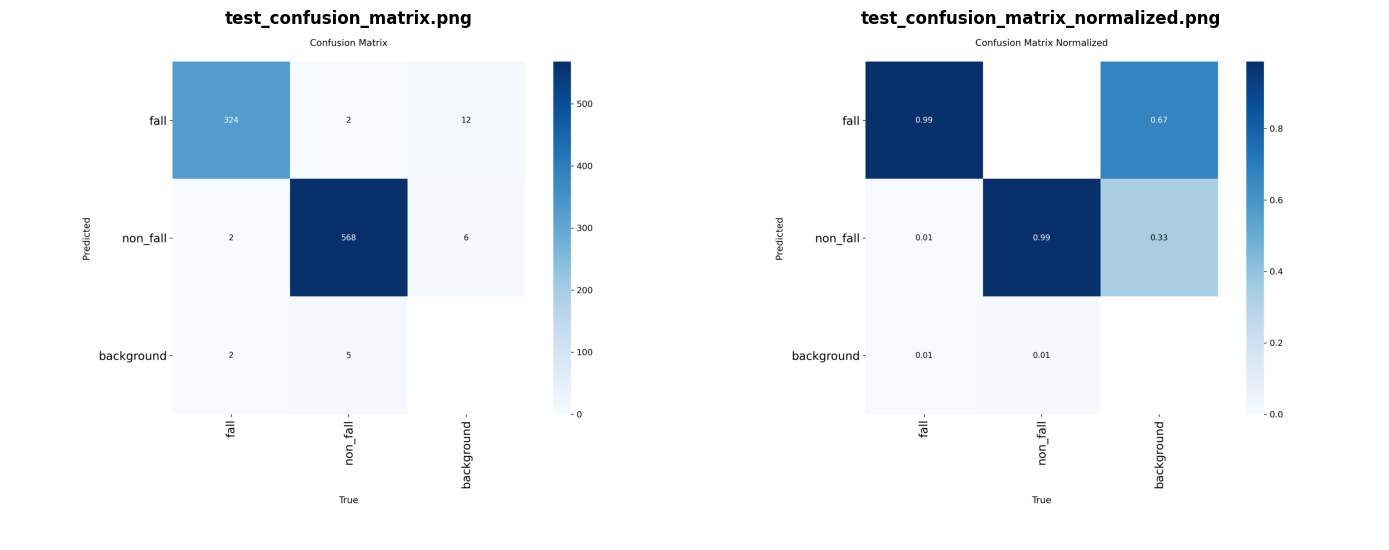

In [ ]:
# ============================================================
# CELDA – Visualizar figuras copiadas para documentación
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import math

FIG_DIR = Path("/content/drive/MyDrive/TFM/figuras_resultados_yolo")

figuras = [
    "test_confusion_matrix.png",
    "test_confusion_matrix_normalized.png",
    "test_PR_curve.png",
    "test_F1_curve.png",
    "test_P_curve.png",
    "test_R_curve.png"
]

figuras_existentes = [
    FIG_DIR / f
    for f in figuras
    if (FIG_DIR / f).exists()
]

print("=" * 70)
print("📊 FIGURAS DISPONIBLES PARA DOCUMENTACIÓN")
print("=" * 70)

print(f"Carpeta: {FIG_DIR}")
print(f"Figuras encontradas: {len(figuras_existentes)}")

for f in figuras_existentes:
    print(f"✅ {f.name}")

if len(figuras_existentes) == 0:
    raise FileNotFoundError("No se encontraron figuras copiadas. Revisa la celda anterior.")

cols = 2
rows = math.ceil(len(figuras_existentes) / cols)

plt.figure(figsize=(14, 6 * rows))

for i, path_img in enumerate(figuras_existentes, start=1):
    img = cv2.imread(str(path_img))

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.title(path_img.name, fontsize=12, fontweight="bold")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELDA – Copiar TODAS las figuras oficiales de YOLO para documentación
# ============================================================

from pathlib import Path
import shutil

TFM_DIR = Path("/content/drive/MyDrive/TFM")

TEST_EVAL_DIR = TFM_DIR / "runs_yolo_caidas" / "baseline_yolov8n_clean_70_15_15_test_eval"
FIG_DIR = TFM_DIR / "figuras_resultados_yolo"
FIG_DIR.mkdir(parents=True, exist_ok=True)

archivos = {
    "confusion_matrix.png": "test_confusion_matrix.png",
    "confusion_matrix_normalized.png": "test_confusion_matrix_normalized.png",

    # En tu versión de Ultralytics las curvas vienen con prefijo Box
    "BoxPR_curve.png": "test_BoxPR_curve.png",
    "BoxF1_curve.png": "test_BoxF1_curve.png",
    "BoxP_curve.png": "test_BoxP_curve.png",
    "BoxR_curve.png": "test_BoxR_curve.png",

    # Imágenes de comparación labels vs predicciones
    "val_batch0_labels.jpg": "test_batch0_labels.jpg",
    "val_batch0_pred.jpg": "test_batch0_pred.jpg",
    "val_batch1_labels.jpg": "test_batch1_labels.jpg",
    "val_batch1_pred.jpg": "test_batch1_pred.jpg",
    "val_batch2_labels.jpg": "test_batch2_labels.jpg",
    "val_batch2_pred.jpg": "test_batch2_pred.jpg",

    # Resumen de métricas
    "metricas_test_resumen.csv": "metricas_test_resumen.csv",
    "metricas_test_resumen.txt": "metricas_test_resumen.txt"
}

print("=" * 70)
print("📁 COPIANDO FIGURAS OFICIALES DE TEST")
print("=" * 70)

print(f"Origen : {TEST_EVAL_DIR}")
print(f"Destino: {FIG_DIR}")

copiados = []
no_encontrados = []

for origen, destino in archivos.items():
    src = TEST_EVAL_DIR / origen
    dst = FIG_DIR / destino

    if src.exists():
        shutil.copy2(src, dst)
        copiados.append(dst)
        print(f"✅ Copiado: {dst.name}")
    else:
        no_encontrados.append(src)
        print(f"⚠️ No encontrado: {src.name}")

print("\n" + "=" * 70)
print("✅ RESUMEN")
print("=" * 70)

print(f"Archivos copiados    : {len(copiados)}")
print(f"Archivos no encontrados: {len(no_encontrados)}")

print("\n📁 Figuras disponibles en:")
print(FIG_DIR)

📁 COPIANDO FIGURAS OFICIALES DE TEST
Origen : /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15_test_eval
Destino: /content/drive/MyDrive/TFM/figuras_resultados_yolo
✅ Copiado: test_confusion_matrix.png
✅ Copiado: test_confusion_matrix_normalized.png
✅ Copiado: test_BoxPR_curve.png
✅ Copiado: test_BoxF1_curve.png
✅ Copiado: test_BoxP_curve.png
✅ Copiado: test_BoxR_curve.png
✅ Copiado: test_batch0_labels.jpg
✅ Copiado: test_batch0_pred.jpg
✅ Copiado: test_batch1_labels.jpg
✅ Copiado: test_batch1_pred.jpg
✅ Copiado: test_batch2_labels.jpg
✅ Copiado: test_batch2_pred.jpg
✅ Copiado: metricas_test_resumen.csv
✅ Copiado: metricas_test_resumen.txt

✅ RESUMEN
Archivos copiados    : 14
Archivos no encontrados: 0

📁 Figuras disponibles en:
/content/drive/MyDrive/TFM/figuras_resultados_yolo


📊 FIGURAS DISPONIBLES PARA DOCUMENTACIÓN
Carpeta: /content/drive/MyDrive/TFM/figuras_resultados_yolo
Figuras encontradas: 12
✅ test_confusion_matrix.png
✅ test_confusion_matrix_normalized.png
✅ test_BoxPR_curve.png
✅ test_BoxF1_curve.png
✅ test_BoxP_curve.png
✅ test_BoxR_curve.png
✅ test_batch0_labels.jpg
✅ test_batch0_pred.jpg
✅ test_batch1_labels.jpg
✅ test_batch1_pred.jpg
✅ test_batch2_labels.jpg
✅ test_batch2_pred.jpg


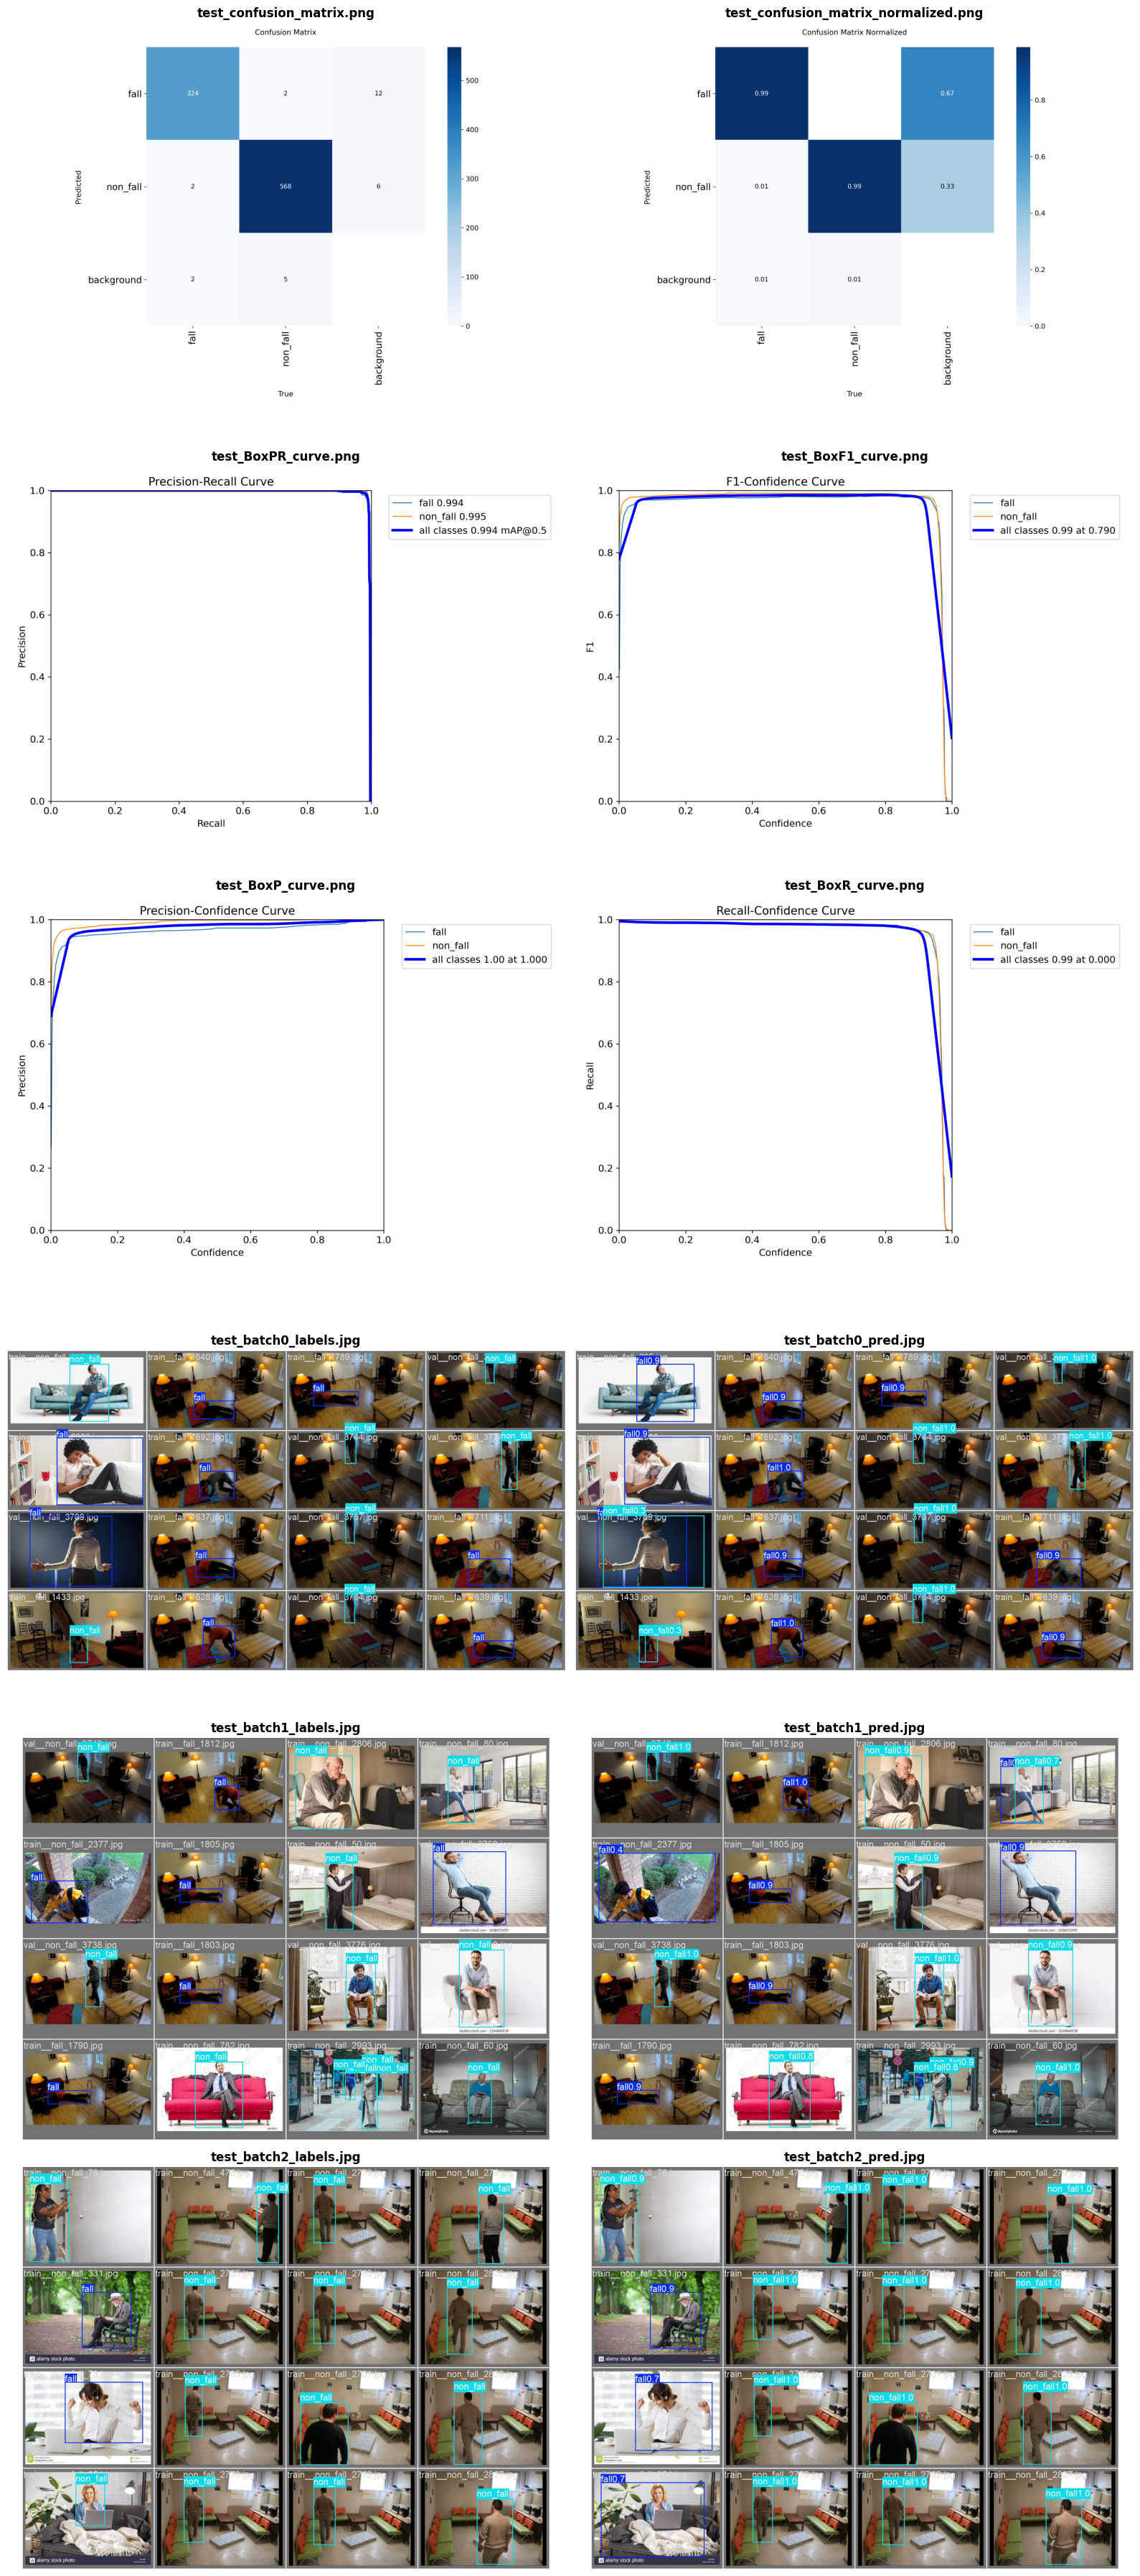

In [ ]:
# ============================================================
# CELDA – Visualizar todas las figuras principales copiadas
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import math

FIG_DIR = Path("/content/drive/MyDrive/TFM/figuras_resultados_yolo")

figuras = [
    "test_confusion_matrix.png",
    "test_confusion_matrix_normalized.png",
    "test_BoxPR_curve.png",
    "test_BoxF1_curve.png",
    "test_BoxP_curve.png",
    "test_BoxR_curve.png",
    "test_batch0_labels.jpg",
    "test_batch0_pred.jpg",
    "test_batch1_labels.jpg",
    "test_batch1_pred.jpg",
    "test_batch2_labels.jpg",
    "test_batch2_pred.jpg"
]

figuras_existentes = [
    FIG_DIR / f
    for f in figuras
    if (FIG_DIR / f).exists()
]

print("=" * 70)
print("📊 FIGURAS DISPONIBLES PARA DOCUMENTACIÓN")
print("=" * 70)

print(f"Carpeta: {FIG_DIR}")
print(f"Figuras encontradas: {len(figuras_existentes)}")

for f in figuras_existentes:
    print(f"✅ {f.name}")

if len(figuras_existentes) == 0:
    raise FileNotFoundError("No se encontraron figuras para mostrar.")

cols = 2
rows = math.ceil(len(figuras_existentes) / cols)

plt.figure(figsize=(16, 6 * rows))

for i, path_img in enumerate(figuras_existentes, start=1):
    img = cv2.imread(str(path_img))

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.title(path_img.name, fontsize=12, fontweight="bold")
    plt.axis("off")

plt.tight_layout()
plt.show()

La matriz de confusión evidencia que el modelo logró clasificar correctamente la mayoría de los casos de las clases fall y non_fall. En la clase fall, se observa una alta concentración en la diagonal principal, lo que indica una adecuada detección de eventos de caída. La presencia de la categoría background corresponde a la representación interna de YOLO para falsos positivos o detecciones no asociadas directamente a una clase objetivo, por lo que no constituye una tercera clase del problema.

In [ ]:
# ============================================================
# CELDA – Copiar figuras oficiales de YOLO para documentación
# ============================================================

from pathlib import Path
import shutil

TFM_DIR = Path("/content/drive/MyDrive/TFM")

TEST_EVAL_DIR = TFM_DIR / "runs_yolo_caidas" / "baseline_yolov8n_clean_70_15_15_test_eval"
FIG_DIR = TFM_DIR / "figuras_resultados_yolo"
FIG_DIR.mkdir(parents=True, exist_ok=True)

archivos = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png"
]

print("=" * 70)
print("📁 COPIANDO FIGURAS OFICIALES DE TEST")
print("=" * 70)

print(f"Origen : {TEST_EVAL_DIR}")
print(f"Destino: {FIG_DIR}")

for nombre in archivos:
    src = TEST_EVAL_DIR / nombre
    dst = FIG_DIR / f"test_{nombre}"

    if src.exists():
        shutil.copy2(src, dst)
        print(f"✅ Copiado: {dst}")
    else:
        print(f"⚠️ No encontrado: {src}")

print("\n✅ Listo. Usa estas figuras en tu documento y sustentación.")

📁 COPIANDO FIGURAS OFICIALES DE TEST
Origen : /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15_test_eval
Destino: /content/drive/MyDrive/TFM/figuras_resultados_yolo
✅ Copiado: /content/drive/MyDrive/TFM/figuras_resultados_yolo/test_confusion_matrix.png
✅ Copiado: /content/drive/MyDrive/TFM/figuras_resultados_yolo/test_confusion_matrix_normalized.png
⚠️ No encontrado: /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15_test_eval/PR_curve.png
⚠️ No encontrado: /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15_test_eval/F1_curve.png
⚠️ No encontrado: /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15_test_eval/P_curve.png
⚠️ No encontrado: /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15_test_eval/R_curve.png

✅ Listo. Usa estas figuras en tu documento y sustentación.


📋 Tabla de métricas TEST:


,clase,imagenes,instancias,precision,recall,mAP50,mAP50_95
0,Global,896,903,0.991,0.981,0.994,0.982
1,fall,326,328,0.983,0.982,0.994,0.979
2,non_fall,570,575,1.000,0.981,0.995,0.985


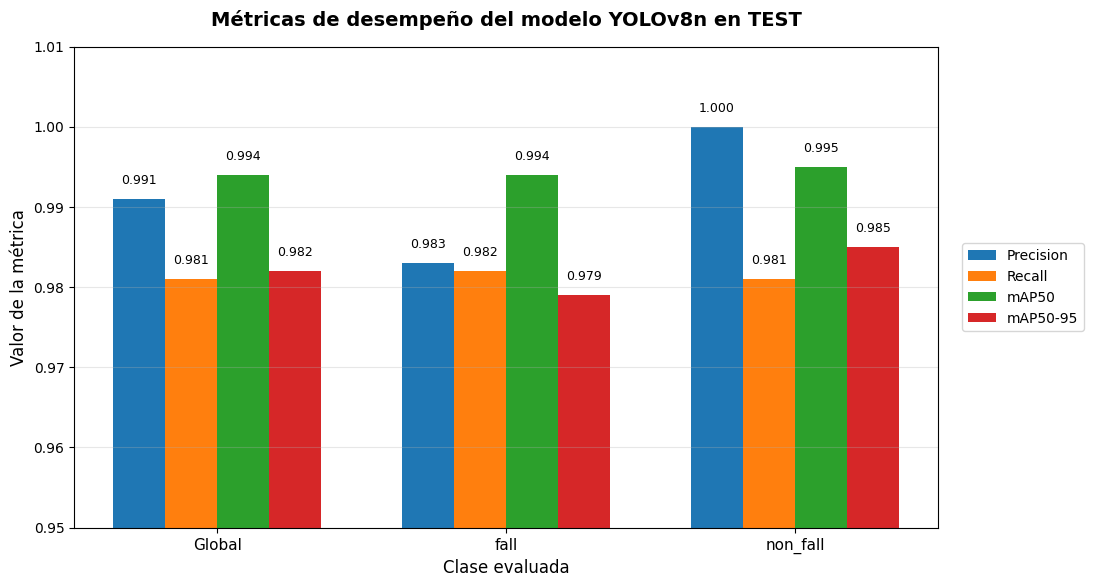

✅ Gráfica corregida guardada en:
/content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_metricas_test_barras_agrupadas_corregida.png
/content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_metricas_test_barras_agrupadas_corregida.pdf


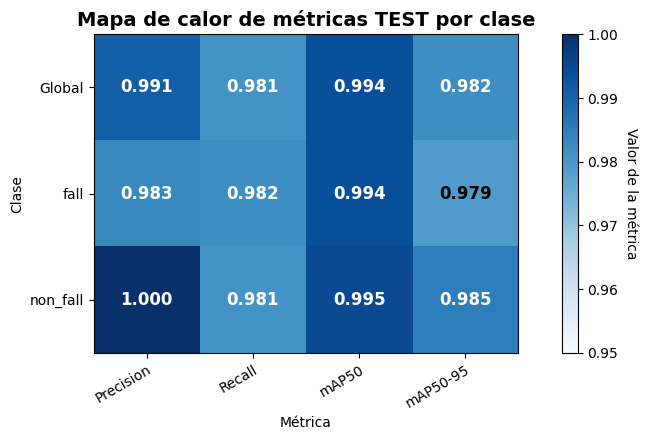

✅ Mapa de calor guardado en:
/content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_metricas_test_mapa_calor.png
/content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_metricas_test_mapa_calor.pdf

✅ FIGURAS DE MÉTRICAS GENERADAS
Archivos principales:
1. fig_metricas_test_barras_agrupadas.png
2. fig_metricas_test_mapa_calor.png


In [ ]:
# ============================================================
# CELDA – Gráfica  de métricas TEST
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Rutas
# ------------------------------------------------------------

TFM_DIR = Path("/content/drive/MyDrive/TFM")
FIG_DIR = TFM_DIR / "figuras_resultados_yolo"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CSV_METRICAS = FIG_DIR / "tabla_metricas_test.csv"

# ------------------------------------------------------------
# 2. Cargar métricas
# ------------------------------------------------------------

if CSV_METRICAS.exists():
    df_metricas = pd.read_csv(CSV_METRICAS)
else:
    df_metricas = pd.DataFrame([
        {"clase": "Global",   "imagenes": 896, "instancias": 903, "precision": 0.991, "recall": 0.981, "mAP50": 0.994, "mAP50_95": 0.982},
        {"clase": "fall",     "imagenes": 326, "instancias": 328, "precision": 0.983, "recall": 0.982, "mAP50": 0.994, "mAP50_95": 0.979},
        {"clase": "non_fall", "imagenes": 570, "instancias": 575, "precision": 1.000, "recall": 0.981, "mAP50": 0.995, "mAP50_95": 0.985}
    ])

print("📋 Tabla de métricas TEST:")
display(df_metricas)

# ------------------------------------------------------------
# 3. Gráfica corregida
# ------------------------------------------------------------

metricas = ["precision", "recall", "mAP50", "mAP50_95"]
labels_metricas = ["Precision", "Recall", "mAP50", "mAP50-95"]

x = np.arange(len(df_metricas["clase"]))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 6.5))

for i, (metrica, label) in enumerate(zip(metricas, labels_metricas)):
    posiciones = x + (i - 1.5) * width
    valores = df_metricas[metrica].values

    barras = ax.bar(posiciones, valores, width, label=label)

    for barra, valor in zip(barras, valores):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            valor + 0.0015,
            f"{valor:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_title(
    "Métricas de desempeño del modelo YOLOv8n en TEST",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Clase evaluada", fontsize=12)
ax.set_ylabel("Valor de la métrica", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(df_metricas["clase"], fontsize=11)

# Más espacio arriba para evitar que se corten los valores
ax.set_ylim(0.95, 1.01)

ax.grid(axis="y", alpha=0.3)

# Mover la leyenda fuera del gráfico
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

# Ajustar márgenes manualmente
plt.subplots_adjust(left=0.10, right=0.82, top=0.88, bottom=0.14)

OUT_PNG = FIG_DIR / "fig_metricas_test_barras_agrupadas_corregida.png"
OUT_PDF = FIG_DIR / "fig_metricas_test_barras_agrupadas_corregida.pdf"

plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight", pad_inches=0.2)
plt.savefig(OUT_PDF, bbox_inches="tight", pad_inches=0.2)
plt.show()

print("✅ Gráfica corregida guardada en:")
print(OUT_PNG)
print(OUT_PDF)
# ------------------------------------------------------------
# 4. Mapa de calor de métricas
# ------------------------------------------------------------

df_heat = df_metricas.set_index("clase")[metricas].copy()
df_heat.columns = metricas_labels

fig, ax = plt.subplots(figsize=(9, 4.5))

im = ax.imshow(df_heat.values, cmap="Blues", vmin=0.95, vmax=1.00)

ax.set_title(
    "Mapa de calor de métricas TEST por clase",
    fontsize=14,
    fontweight="bold"
)

ax.set_xticks(np.arange(len(metricas_labels)))
ax.set_yticks(np.arange(len(df_heat.index)))

ax.set_xticklabels(metricas_labels)
ax.set_yticklabels(df_heat.index)

plt.setp(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
    rotation_mode="anchor"
)

for i in range(df_heat.shape[0]):
    for j in range(df_heat.shape[1]):
        valor = df_heat.iloc[i, j]

        ax.text(
            j,
            i,
            f"{valor:.3f}",
            ha="center",
            va="center",
            color="white" if valor >= 0.98 else "black",
            fontsize=12,
            fontweight="bold"
        )

cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Valor de la métrica", rotation=-90, va="bottom")

ax.set_xlabel("Métrica")
ax.set_ylabel("Clase")

plt.tight_layout()

OUT_HEATMAP_PNG = FIG_DIR / "fig_metricas_test_mapa_calor.png"
OUT_HEATMAP_PDF = FIG_DIR / "fig_metricas_test_mapa_calor.pdf"

plt.savefig(OUT_HEATMAP_PNG, dpi=300, bbox_inches="tight")
plt.savefig(OUT_HEATMAP_PDF, bbox_inches="tight")

plt.show()

print("✅ Mapa de calor guardado en:")
print(OUT_HEATMAP_PNG)
print(OUT_HEATMAP_PDF)

# ------------------------------------------------------------
# 5. Resumen final
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✅ FIGURAS DE MÉTRICAS GENERADAS")
print("=" * 70)

print("Archivos principales:")
print(f"1. {OUT_BARRAS_PNG.name}")
print(f"2. {OUT_HEATMAP_PNG.name}")

📋 Distribución de clases por split:


,split,clase,cantidad
0,train,fall,2267
1,train,non_fall,2673
2,val,fall,327
3,val,non_fall,573
4,test,fall,326
5,test,non_fall,570



📋 Tabla absoluta:


split,train,val,test
clase,,,
fall,2267,327,326
non_fall,2673,573,570



📋 Tabla porcentual:


split,train,val,test
clase,,,
fall,45.89,36.33,36.38
non_fall,54.11,63.67,63.62


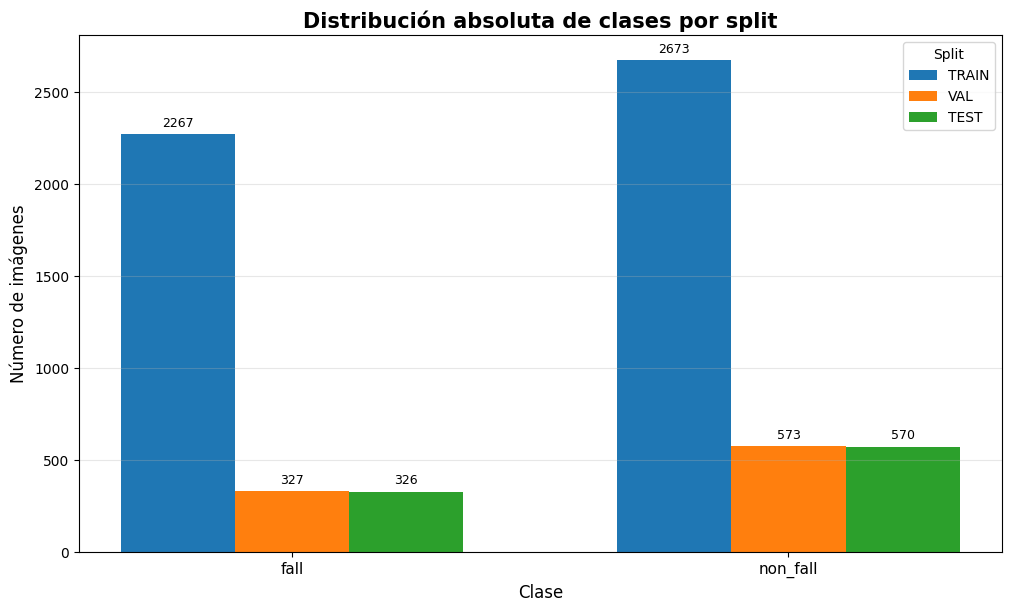

✅ Gráfica de barras absolutas guardada en:
/content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_distribucion_clases_barras_absolutas.png
/content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_distribucion_clases_barras_absolutas.pdf


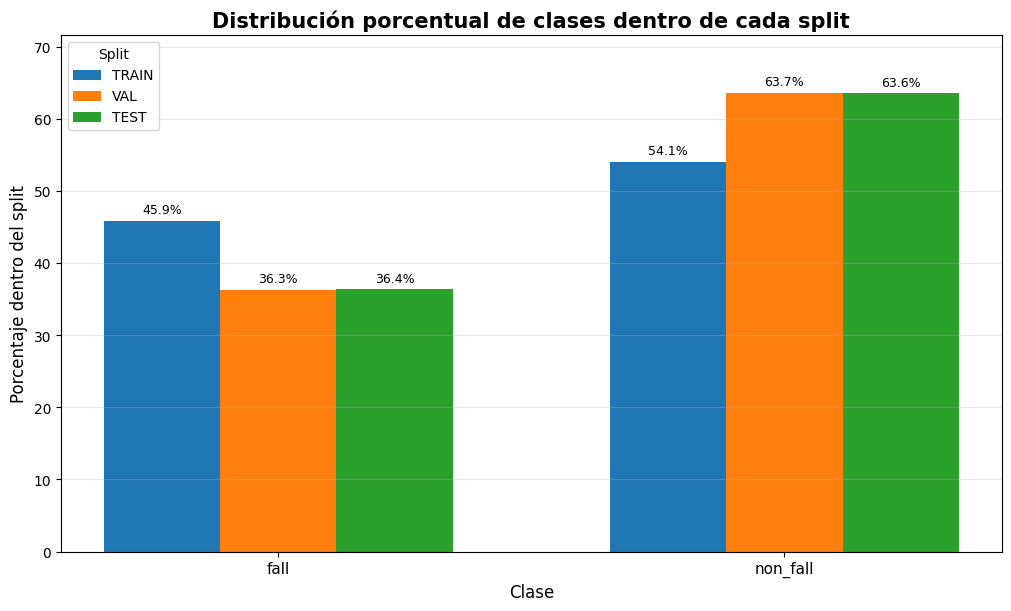

✅ Gráfica de barras porcentuales guardada en:
/content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_distribucion_clases_barras_porcentuales.png
/content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_distribucion_clases_barras_porcentuales.pdf


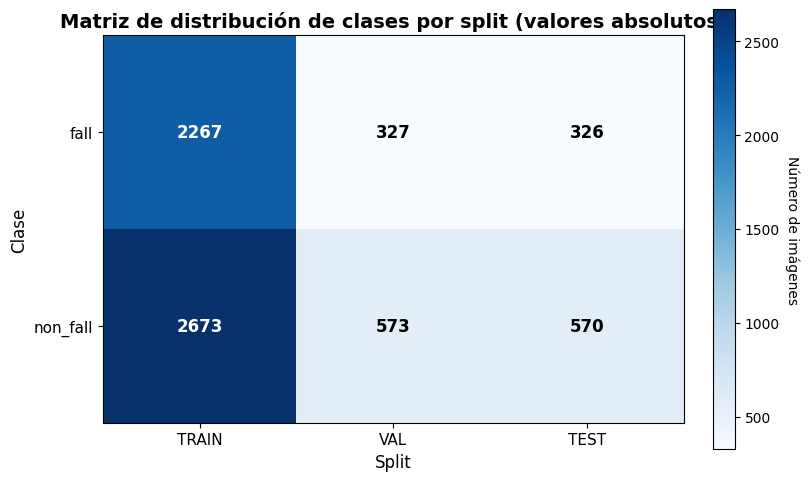

✅ Heatmap absoluto guardado en:
/content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_matriz_distribucion_clases_absoluta.png
/content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_matriz_distribucion_clases_absoluta.pdf


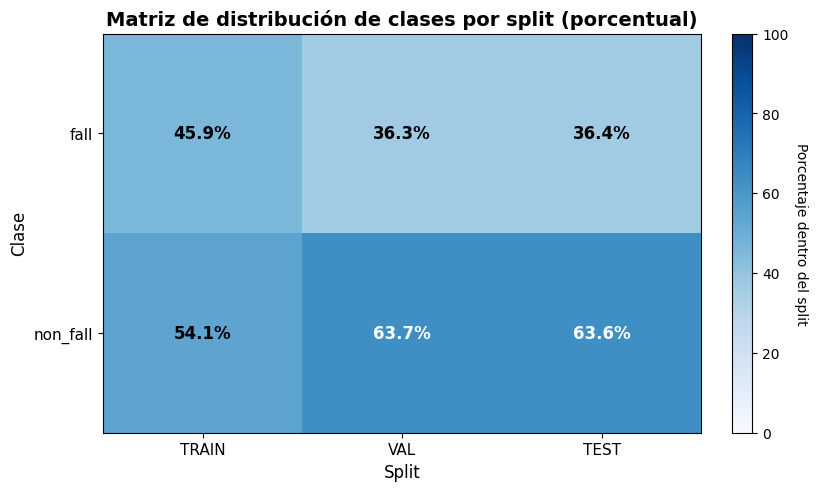

✅ Heatmap porcentual guardado en:
/content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_matriz_distribucion_clases_porcentual.png
/content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_matriz_distribucion_clases_porcentual.pdf

✅ FIGURAS DE DISTRIBUCIÓN GENERADAS
Archivos recomendados:
1. fig_distribucion_clases_barras_absolutas.png
2. fig_distribucion_clases_barras_porcentuales.png
3. fig_matriz_distribucion_clases_absoluta.png
4. fig_matriz_distribucion_clases_porcentual.png


In [ ]:
# ============================================================
# CELDA – Distribución de clases: gráficas y matriz elegante
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Rutas
# ------------------------------------------------------------

TFM_DIR = Path("/content/drive/MyDrive/TFM")
FIG_DIR = TFM_DIR / "figuras_resultados_yolo"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. Tabla base
#    (puedes reemplazarla por tu df_dist si ya existe)
# ------------------------------------------------------------

df_dist = pd.DataFrame([
    {"split": "train", "clase": "fall",     "cantidad": 2267},
    {"split": "train", "clase": "non_fall", "cantidad": 2673},
    {"split": "val",   "clase": "fall",     "cantidad": 327},
    {"split": "val",   "clase": "non_fall", "cantidad": 573},
    {"split": "test",  "clase": "fall",     "cantidad": 326},
    {"split": "test",  "clase": "non_fall", "cantidad": 570},
])

print("📋 Distribución de clases por split:")
display(df_dist)

# Orden deseado
splits = ["train", "val", "test"]
clases = ["fall", "non_fall"]

# Tabla pivote: filas = clase, columnas = split
tabla_abs = df_dist.pivot(index="clase", columns="split", values="cantidad").reindex(clases)[splits]

# Tabla porcentual por split
tabla_pct = tabla_abs.copy().astype(float)
for split in splits:
    total_split = tabla_pct[split].sum()
    tabla_pct[split] = 100 * tabla_pct[split] / total_split

print("\n📋 Tabla absoluta:")
display(tabla_abs)

print("\n📋 Tabla porcentual:")
display(tabla_pct.round(2))

# ------------------------------------------------------------
# 3. Gráfica de barras – cantidades absolutas
# ------------------------------------------------------------

x = np.arange(len(clases))
width = 0.23

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

for i, split in enumerate(splits):
    valores = tabla_abs[split].values
    barras = ax.bar(x + (i - 1) * width, valores, width, label=split.upper())

    for barra, valor in zip(barras, valores):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            valor + max(tabla_abs.values.flatten()) * 0.01,
            f"{int(valor)}",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_title(
    "Distribución absoluta de clases por split",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Clase", fontsize=12)
ax.set_ylabel("Número de imágenes", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(clases, fontsize=11)
ax.legend(title="Split")
ax.grid(axis="y", alpha=0.3)

OUT_BAR_ABS_PNG = FIG_DIR / "fig_distribucion_clases_barras_absolutas.png"
OUT_BAR_ABS_PDF = FIG_DIR / "fig_distribucion_clases_barras_absolutas.pdf"

plt.savefig(OUT_BAR_ABS_PNG, dpi=300, bbox_inches="tight", pad_inches=0.2)
plt.savefig(OUT_BAR_ABS_PDF, bbox_inches="tight", pad_inches=0.2)
plt.show()

print("✅ Gráfica de barras absolutas guardada en:")
print(OUT_BAR_ABS_PNG)
print(OUT_BAR_ABS_PDF)

# ------------------------------------------------------------
# 4. Gráfica de barras – porcentajes por split
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

for i, split in enumerate(splits):
    valores = tabla_pct[split].values
    barras = ax.bar(x + (i - 1) * width, valores, width, label=split.upper())

    for barra, valor in zip(barras, valores):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            valor + 0.6,
            f"{valor:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_title(
    "Distribución porcentual de clases dentro de cada split",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Clase", fontsize=12)
ax.set_ylabel("Porcentaje dentro del split", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(clases, fontsize=11)
ax.set_ylim(0, max(tabla_pct.values.flatten()) + 8)
ax.legend(title="Split")
ax.grid(axis="y", alpha=0.3)

OUT_BAR_PCT_PNG = FIG_DIR / "fig_distribucion_clases_barras_porcentuales.png"
OUT_BAR_PCT_PDF = FIG_DIR / "fig_distribucion_clases_barras_porcentuales.pdf"

plt.savefig(OUT_BAR_PCT_PNG, dpi=300, bbox_inches="tight", pad_inches=0.2)
plt.savefig(OUT_BAR_PCT_PDF, bbox_inches="tight", pad_inches=0.2)
plt.show()

print("✅ Gráfica de barras porcentuales guardada en:")
print(OUT_BAR_PCT_PNG)
print(OUT_BAR_PCT_PDF)

# ------------------------------------------------------------
# 5. Heatmap / matriz bonita – valores absolutos
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 4.8), constrained_layout=True)

mat = tabla_abs.values
im = ax.imshow(mat, cmap="Blues")

ax.set_title(
    "Matriz de distribución de clases por split (valores absolutos)",
    fontsize=14,
    fontweight="bold"
)

ax.set_xticks(np.arange(len(splits)))
ax.set_yticks(np.arange(len(clases)))
ax.set_xticklabels([s.upper() for s in splits], fontsize=11)
ax.set_yticklabels(clases, fontsize=11)

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        valor = int(mat[i, j])
        ax.text(
            j, i, f"{valor}",
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            color="white" if valor > mat.max() * 0.55 else "black"
        )

cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Número de imágenes", rotation=-90, va="bottom")

ax.set_xlabel("Split", fontsize=12)
ax.set_ylabel("Clase", fontsize=12)

OUT_HEAT_ABS_PNG = FIG_DIR / "fig_matriz_distribucion_clases_absoluta.png"
OUT_HEAT_ABS_PDF = FIG_DIR / "fig_matriz_distribucion_clases_absoluta.pdf"

plt.savefig(OUT_HEAT_ABS_PNG, dpi=300, bbox_inches="tight", pad_inches=0.2)
plt.savefig(OUT_HEAT_ABS_PDF, bbox_inches="tight", pad_inches=0.2)
plt.show()

print("✅ Heatmap absoluto guardado en:")
print(OUT_HEAT_ABS_PNG)
print(OUT_HEAT_ABS_PDF)

# ------------------------------------------------------------
# 6. Heatmap / matriz bonita – porcentajes normalizados
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 4.8), constrained_layout=True)

mat_pct = tabla_pct.values
im = ax.imshow(mat_pct, cmap="Blues", vmin=0, vmax=100)

ax.set_title(
    "Matriz de distribución de clases por split (porcentual)",
    fontsize=14,
    fontweight="bold"
)

ax.set_xticks(np.arange(len(splits)))
ax.set_yticks(np.arange(len(clases)))
ax.set_xticklabels([s.upper() for s in splits], fontsize=11)
ax.set_yticklabels(clases, fontsize=11)

for i in range(mat_pct.shape[0]):
    for j in range(mat_pct.shape[1]):
        valor = mat_pct[i, j]
        ax.text(
            j, i, f"{valor:.1f}%",
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            color="white" if valor > 55 else "black"
        )

cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Porcentaje dentro del split", rotation=-90, va="bottom")

ax.set_xlabel("Split", fontsize=12)
ax.set_ylabel("Clase", fontsize=12)

OUT_HEAT_PCT_PNG = FIG_DIR / "fig_matriz_distribucion_clases_porcentual.png"
OUT_HEAT_PCT_PDF = FIG_DIR / "fig_matriz_distribucion_clases_porcentual.pdf"

plt.savefig(OUT_HEAT_PCT_PNG, dpi=300, bbox_inches="tight", pad_inches=0.2)
plt.savefig(OUT_HEAT_PCT_PDF, bbox_inches="tight", pad_inches=0.2)
plt.show()

print("✅ Heatmap porcentual guardado en:")
print(OUT_HEAT_PCT_PNG)
print(OUT_HEAT_PCT_PDF)

# ------------------------------------------------------------
# 7. Resumen
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✅ FIGURAS DE DISTRIBUCIÓN GENERADAS")
print("=" * 70)

print("Archivos recomendados:")
print(f"1. {OUT_BAR_ABS_PNG.name}")
print(f"2. {OUT_BAR_PCT_PNG.name}")
print(f"3. {OUT_HEAT_ABS_PNG.name}")
print(f"4. {OUT_HEAT_PCT_PNG.name}")

📈 CURVAS DE MÉTRICAS DEL ENTRENAMIENTO
results.csv : /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15/results.csv
Existe?     : True
Salida      : /content/drive/MyDrive/TFM/figuras_resultados_yolo

Columnas disponibles:
 - epoch
 - time
 - train/box_loss
 - train/cls_loss
 - train/dfl_loss
 - metrics/precision(B)
 - metrics/recall(B)
 - metrics/mAP50(B)
 - metrics/mAP50-95(B)
 - val/box_loss
 - val/cls_loss
 - val/dfl_loss
 - lr/pg0
 - lr/pg1
 - lr/pg2

Métricas detectadas:
✅ Precision: metrics/precision(B)
✅ Recall: metrics/recall(B)
✅ mAP50: metrics/mAP50(B)
✅ mAP50-95: metrics/mAP50-95(B)

📋 Mejores valores por métrica:


,metrica,mejor_valor,epoca_mejor
0,Precision,0.99442,39
1,Recall,0.99121,50
2,mAP50,0.99473,50
3,mAP50-95,0.97819,49


✅ Resumen guardado en: /content/drive/MyDrive/TFM/figuras_resultados_yolo/tabla_mejores_metricas_entrenamiento.csv


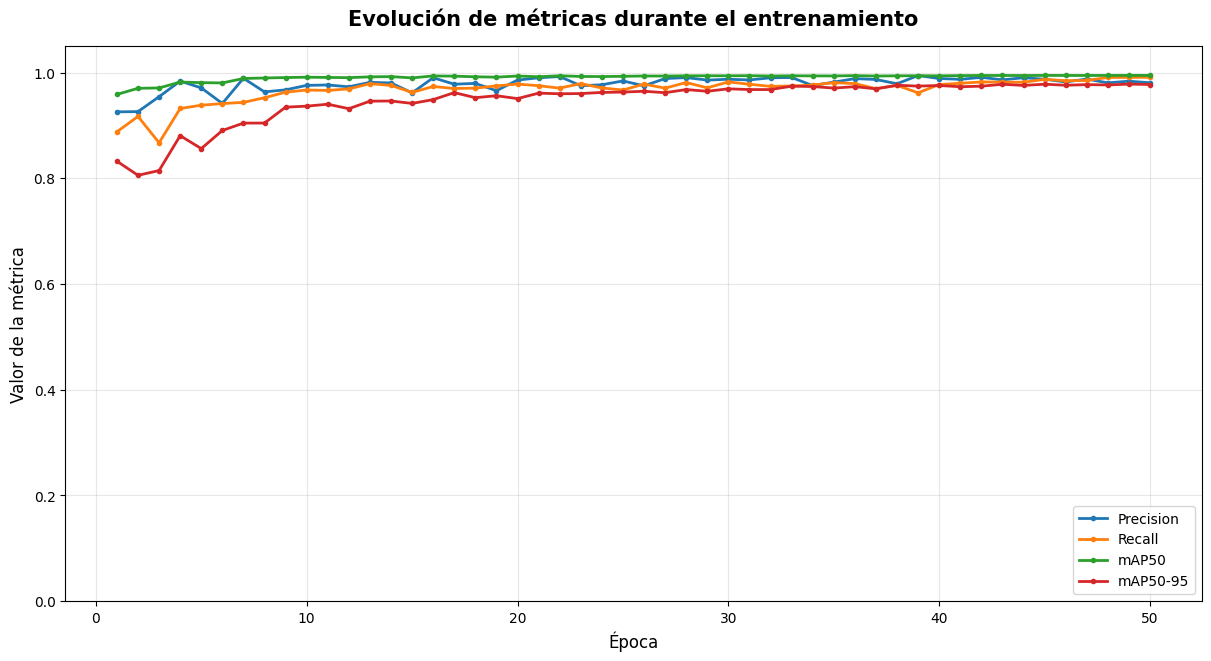

✅ Curva completa guardada en:
/content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_curvas_metricas_entrenamiento_completa.png
/content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_curvas_metricas_entrenamiento_completa.pdf


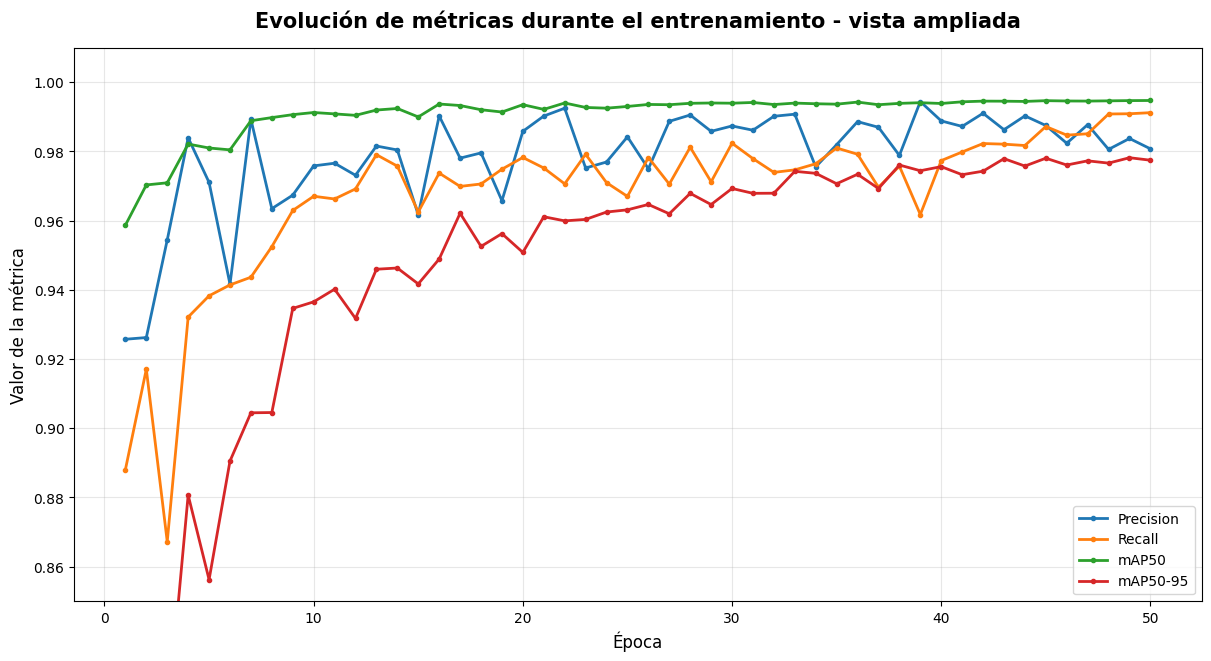

✅ Curva ampliada guardada en:
/content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_curvas_metricas_entrenamiento_zoom.png
/content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_curvas_metricas_entrenamiento_zoom.pdf


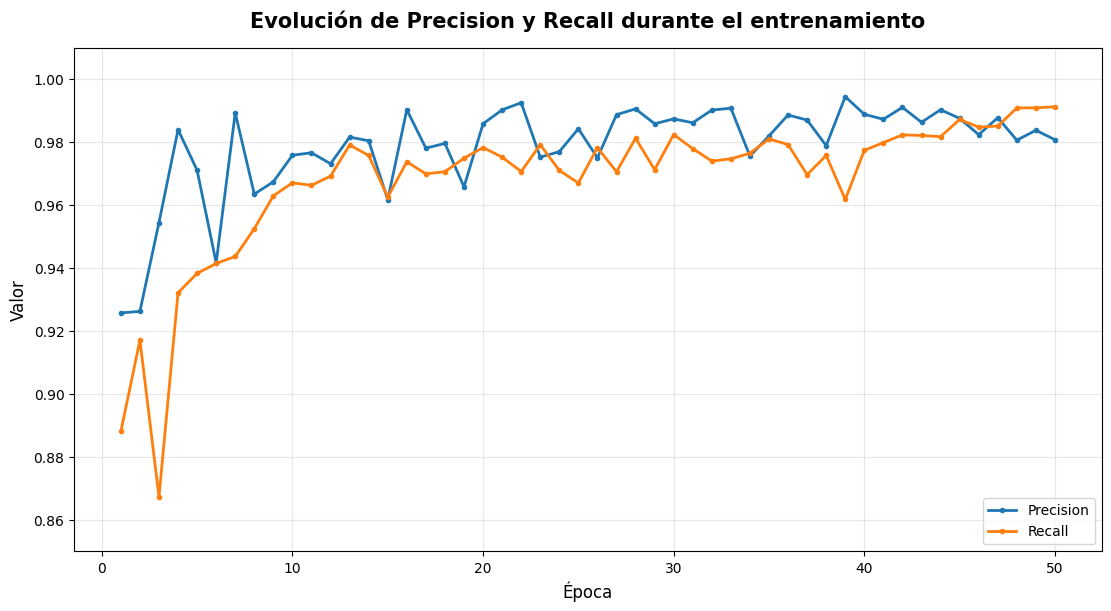

✅ Curva Precision/Recall guardada en:
/content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_curvas_precision_recall_entrenamiento.png
/content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_curvas_precision_recall_entrenamiento.pdf


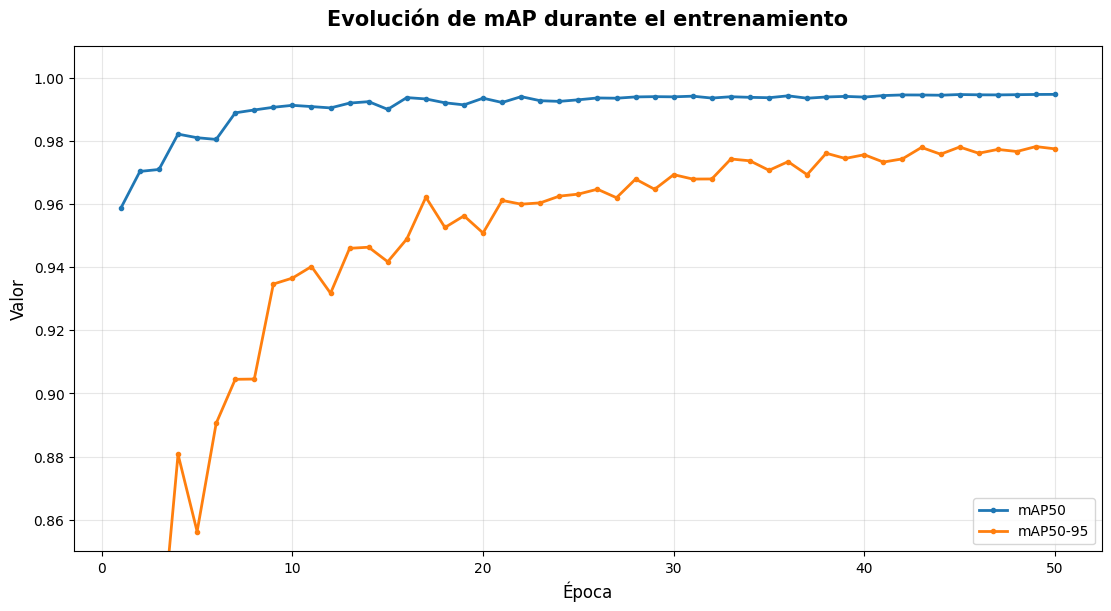

✅ Curva mAP guardada en:
/content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_curvas_map_entrenamiento.png
/content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_curvas_map_entrenamiento.pdf

✅ CURVAS DE MÉTRICAS GENERADAS
Archivos principales:
1. fig_curvas_metricas_entrenamiento_completa.png
2. fig_curvas_metricas_entrenamiento_zoom.png
3. fig_curvas_precision_recall_entrenamiento.png
4. fig_curvas_map_entrenamiento.png

Carpeta de salida:
/content/drive/MyDrive/TFM/figuras_resultados_yolo


In [ ]:
# ============================================================
# CELDA – Curvas de métricas del entrenamiento YOLOv8n
#
# Genera:
#   1. Curva completa de métricas
#   2. Curva ampliada tipo zoom
#   3. Curva solo Precision / Recall
#   4. Curva solo mAP50 / mAP50-95
#
# Salidas:
#   /content/drive/MyDrive/TFM/figuras_resultados_yolo
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Rutas
# ------------------------------------------------------------

TFM_DIR = Path("/content/drive/MyDrive/TFM")

RUN_DIR = TFM_DIR / "runs_yolo_caidas" / "baseline_yolov8n_clean_70_15_15"
RESULTS_CSV = RUN_DIR / "results.csv"

FIG_DIR = TFM_DIR / "figuras_resultados_yolo"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("📈 CURVAS DE MÉTRICAS DEL ENTRENAMIENTO")
print("=" * 70)

print(f"results.csv : {RESULTS_CSV}")
print(f"Existe?     : {RESULTS_CSV.exists()}")
print(f"Salida      : {FIG_DIR}")

if not RESULTS_CSV.exists():
    raise FileNotFoundError(f"No se encontró results.csv en:\n{RESULTS_CSV}")

# ------------------------------------------------------------
# 2. Cargar results.csv
# ------------------------------------------------------------

df_results = pd.read_csv(RESULTS_CSV)

# Limpiar nombres de columnas
df_results.columns = [c.strip() for c in df_results.columns]

print("\nColumnas disponibles:")
for c in df_results.columns:
    print(" -", c)

# Asegurar columna epoch
if "epoch" not in df_results.columns:
    df_results["epoch"] = np.arange(1, len(df_results) + 1)

# ------------------------------------------------------------
# 3. Detectar columnas de métricas
# ------------------------------------------------------------

metricas = {
    "Precision": "metrics/precision(B)",
    "Recall": "metrics/recall(B)",
    "mAP50": "metrics/mAP50(B)",
    "mAP50-95": "metrics/mAP50-95(B)"
}

metricas_disponibles = {
    nombre: col
    for nombre, col in metricas.items()
    if col in df_results.columns
}

if len(metricas_disponibles) == 0:
    raise ValueError(
        "No se encontraron columnas de métricas en results.csv. "
        "Revisa los nombres impresos arriba."
    )

print("\nMétricas detectadas:")
for nombre, col in metricas_disponibles.items():
    print(f"✅ {nombre}: {col}")

# ------------------------------------------------------------
# 4. Tabla resumen de mejores valores
# ------------------------------------------------------------

filas_resumen = []

for nombre, col in metricas_disponibles.items():
    idx_best = df_results[col].idxmax()

    filas_resumen.append({
        "metrica": nombre,
        "mejor_valor": df_results.loc[idx_best, col],
        "epoca_mejor": int(df_results.loc[idx_best, "epoch"])
    })

df_resumen_metricas = pd.DataFrame(filas_resumen)

OUT_RESUMEN = FIG_DIR / "tabla_mejores_metricas_entrenamiento.csv"
df_resumen_metricas.to_csv(OUT_RESUMEN, index=False)

print("\n📋 Mejores valores por métrica:")
display(df_resumen_metricas)

print(f"✅ Resumen guardado en: {OUT_RESUMEN}")

# ------------------------------------------------------------
# 5. Curva completa de métricas
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6.5), constrained_layout=True)

for nombre, col in metricas_disponibles.items():
    ax.plot(
        df_results["epoch"],
        df_results[col],
        marker="o",
        markersize=3,
        linewidth=2,
        label=nombre
    )

ax.set_title(
    "Evolución de métricas durante el entrenamiento",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("Valor de la métrica", fontsize=12)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend(loc="lower right")

OUT_COMPLETA_PNG = FIG_DIR / "fig_curvas_metricas_entrenamiento_completa.png"
OUT_COMPLETA_PDF = FIG_DIR / "fig_curvas_metricas_entrenamiento_completa.pdf"

plt.savefig(OUT_COMPLETA_PNG, dpi=300, bbox_inches="tight", pad_inches=0.2)
plt.savefig(OUT_COMPLETA_PDF, bbox_inches="tight", pad_inches=0.2)
plt.show()

print("✅ Curva completa guardada en:")
print(OUT_COMPLETA_PNG)
print(OUT_COMPLETA_PDF)

# ------------------------------------------------------------
# 6. Curva ampliada tipo zoom
#    Útil cuando todas las métricas están muy altas
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6.5), constrained_layout=True)

for nombre, col in metricas_disponibles.items():
    ax.plot(
        df_results["epoch"],
        df_results[col],
        marker="o",
        markersize=3,
        linewidth=2,
        label=nombre
    )

ax.set_title(
    "Evolución de métricas durante el entrenamiento - vista ampliada",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("Valor de la métrica", fontsize=12)

# Ajusta este rango si quieres más o menos zoom
ax.set_ylim(0.85, 1.01)

ax.grid(alpha=0.3)
ax.legend(loc="lower right")

OUT_ZOOM_PNG = FIG_DIR / "fig_curvas_metricas_entrenamiento_zoom.png"
OUT_ZOOM_PDF = FIG_DIR / "fig_curvas_metricas_entrenamiento_zoom.pdf"

plt.savefig(OUT_ZOOM_PNG, dpi=300, bbox_inches="tight", pad_inches=0.2)
plt.savefig(OUT_ZOOM_PDF, bbox_inches="tight", pad_inches=0.2)
plt.show()

print("✅ Curva ampliada guardada en:")
print(OUT_ZOOM_PNG)
print(OUT_ZOOM_PDF)

# ------------------------------------------------------------
# 7. Curva Precision y Recall
# ------------------------------------------------------------

cols_pr = {
    "Precision": "metrics/precision(B)",
    "Recall": "metrics/recall(B)"
}

cols_pr = {
    nombre: col
    for nombre, col in cols_pr.items()
    if col in df_results.columns
}

if len(cols_pr) > 0:

    fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)

    for nombre, col in cols_pr.items():
        ax.plot(
            df_results["epoch"],
            df_results[col],
            marker="o",
            markersize=3,
            linewidth=2,
            label=nombre
        )

    ax.set_title(
        "Evolución de Precision y Recall durante el entrenamiento",
        fontsize=15,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel("Época", fontsize=12)
    ax.set_ylabel("Valor", fontsize=12)
    ax.set_ylim(0.85, 1.01)
    ax.grid(alpha=0.3)
    ax.legend(loc="lower right")

    OUT_PR_PNG = FIG_DIR / "fig_curvas_precision_recall_entrenamiento.png"
    OUT_PR_PDF = FIG_DIR / "fig_curvas_precision_recall_entrenamiento.pdf"

    plt.savefig(OUT_PR_PNG, dpi=300, bbox_inches="tight", pad_inches=0.2)
    plt.savefig(OUT_PR_PDF, bbox_inches="tight", pad_inches=0.2)
    plt.show()

    print("✅ Curva Precision/Recall guardada en:")
    print(OUT_PR_PNG)
    print(OUT_PR_PDF)

# ------------------------------------------------------------
# 8. Curva mAP50 y mAP50-95
# ------------------------------------------------------------

cols_map = {
    "mAP50": "metrics/mAP50(B)",
    "mAP50-95": "metrics/mAP50-95(B)"
}

cols_map = {
    nombre: col
    for nombre, col in cols_map.items()
    if col in df_results.columns
}

if len(cols_map) > 0:

    fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)

    for nombre, col in cols_map.items():
        ax.plot(
            df_results["epoch"],
            df_results[col],
            marker="o",
            markersize=3,
            linewidth=2,
            label=nombre
        )

    ax.set_title(
        "Evolución de mAP durante el entrenamiento",
        fontsize=15,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel("Época", fontsize=12)
    ax.set_ylabel("Valor", fontsize=12)
    ax.set_ylim(0.85, 1.01)
    ax.grid(alpha=0.3)
    ax.legend(loc="lower right")

    OUT_MAP_PNG = FIG_DIR / "fig_curvas_map_entrenamiento.png"
    OUT_MAP_PDF = FIG_DIR / "fig_curvas_map_entrenamiento.pdf"

    plt.savefig(OUT_MAP_PNG, dpi=300, bbox_inches="tight", pad_inches=0.2)
    plt.savefig(OUT_MAP_PDF, bbox_inches="tight", pad_inches=0.2)
    plt.show()

    print("✅ Curva mAP guardada en:")
    print(OUT_MAP_PNG)
    print(OUT_MAP_PDF)

# ------------------------------------------------------------
# 9. Resumen final
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✅ CURVAS DE MÉTRICAS GENERADAS")
print("=" * 70)

print("Archivos principales:")
print(f"1. {OUT_COMPLETA_PNG.name}")
print(f"2. {OUT_ZOOM_PNG.name}")

if len(cols_pr) > 0:
    print(f"3. {OUT_PR_PNG.name}")

if len(cols_map) > 0:
    print(f"4. {OUT_MAP_PNG.name}")

print(f"\nCarpeta de salida:\n{FIG_DIR}")

📄 CSV DE PÉRDIDAS CREADO
/content/drive/MyDrive/TFM/figuras_resultados_yolo/results_loss_recuperado_notebook.csv


,epoch,box_loss,cls_loss,dfl_loss,precision,recall,mAP50,mAP50_95
0,1,0.7368,1.3970,1.032,0.926,0.888,0.959,0.832
1,2,0.8210,0.9480,1.063,0.926,0.917,0.970,0.806
2,3,0.8272,0.8155,1.061,0.954,0.867,0.971,0.815
3,4,0.7895,0.7333,1.043,0.984,0.932,0.982,0.881
4,5,0.7536,0.6724,1.025,0.971,0.938,0.981,0.856


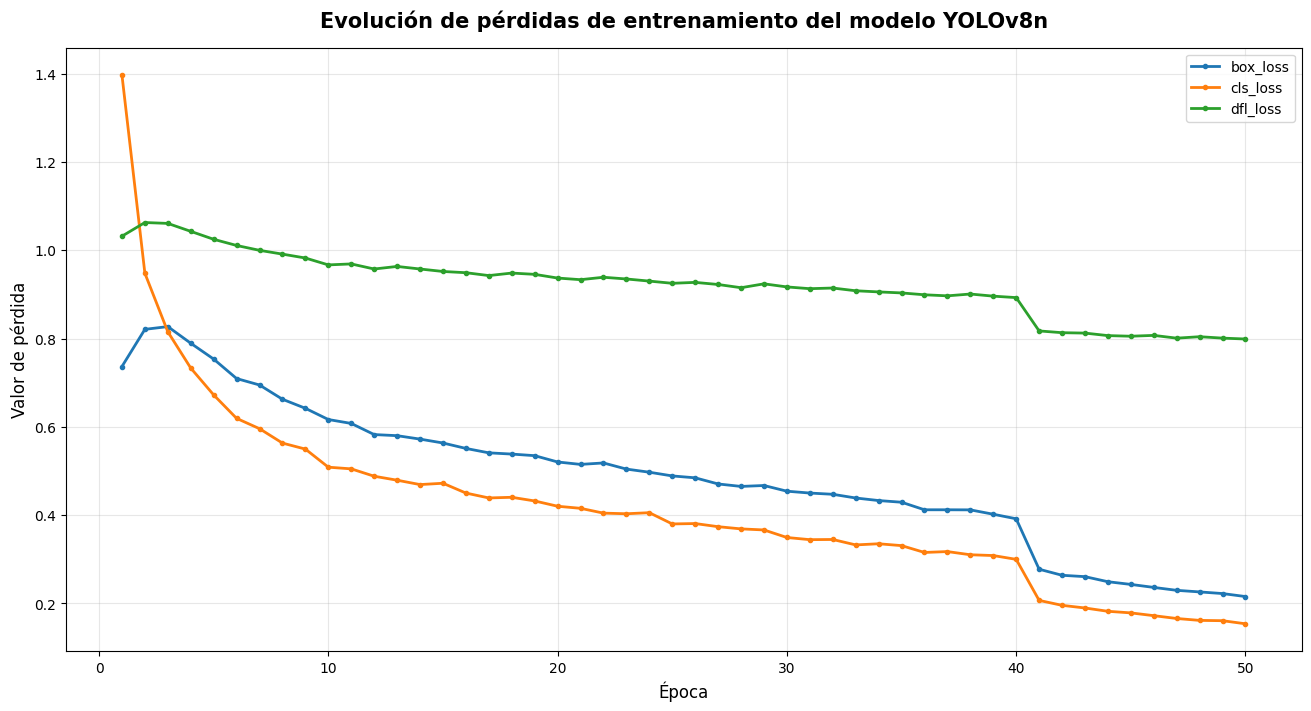


✅ CURVA DE PÉRDIDAS GENERADA
PNG: /content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_curvas_loss_entrenamiento_recuperada.png
PDF: /content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_curvas_loss_entrenamiento_recuperada.pdf


In [ ]:
# ============================================================
# CELDA – Crear curva de pérdidas recuperada directamente
#         SIN YOLO, SIN GPU, SIN REENTRENAR
# ============================================================

from pathlib import Path
from io import StringIO
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Carpeta de salida
# ------------------------------------------------------------

FIG_DIR = Path("/content/drive/MyDrive/TFM/figuras_resultados_yolo")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. Datos recuperados del log del notebook
#    Contienen pérdidas de ENTRENAMIENTO:
#    box_loss, cls_loss, dfl_loss
# ------------------------------------------------------------

csv_data = """epoch,box_loss,cls_loss,dfl_loss,precision,recall,mAP50,mAP50_95
1,0.7368,1.397,1.032,0.926,0.888,0.959,0.832
2,0.821,0.948,1.063,0.926,0.917,0.970,0.806
3,0.8272,0.8155,1.061,0.954,0.867,0.971,0.815
4,0.7895,0.7333,1.043,0.984,0.932,0.982,0.881
5,0.7536,0.6724,1.025,0.971,0.938,0.981,0.856
6,0.7095,0.6193,1.011,0.942,0.941,0.980,0.891
7,0.6949,0.5959,1.000,0.989,0.944,0.989,0.904
8,0.6626,0.5633,0.9914,0.963,0.952,0.990,0.905
9,0.6421,0.5497,0.9826,0.967,0.963,0.991,0.935
10,0.6167,0.5087,0.967,0.976,0.967,0.991,0.937
11,0.6078,0.5049,0.9692,0.977,0.966,0.991,0.940
12,0.5826,0.4882,0.9577,0.973,0.969,0.990,0.932
13,0.5801,0.4792,0.9635,0.982,0.979,0.992,0.946
14,0.5723,0.4693,0.9577,0.980,0.976,0.992,0.946
15,0.5635,0.4723,0.9521,0.962,0.962,0.990,0.942
16,0.5512,0.4501,0.9493,0.990,0.974,0.994,0.949
17,0.5412,0.4390,0.9428,0.978,0.970,0.993,0.962
18,0.5384,0.4405,0.9485,0.980,0.971,0.992,0.953
19,0.5348,0.4322,0.9456,0.966,0.975,0.991,0.956
20,0.5205,0.4202,0.9372,0.986,0.978,0.994,0.951
21,0.5150,0.4155,0.9335,0.990,0.975,0.992,0.961
22,0.5183,0.4046,0.9390,0.992,0.971,0.994,0.960
23,0.5044,0.4032,0.9351,0.975,0.979,0.993,0.960
24,0.4973,0.4056,0.9303,0.977,0.971,0.993,0.962
25,0.4889,0.3801,0.9253,0.984,0.967,0.993,0.963
26,0.4846,0.3810,0.9274,0.975,0.978,0.994,0.965
27,0.4707,0.3739,0.9226,0.989,0.971,0.994,0.962
28,0.4651,0.3689,0.9153,0.991,0.981,0.994,0.968
29,0.4672,0.3665,0.9241,0.986,0.971,0.994,0.965
30,0.4543,0.3494,0.9171,0.987,0.982,0.994,0.969
31,0.4501,0.3445,0.9131,0.986,0.978,0.994,0.968
32,0.4473,0.3449,0.9146,0.990,0.974,0.994,0.968
33,0.4389,0.3326,0.9084,0.991,0.975,0.994,0.974
34,0.4331,0.3352,0.9058,0.976,0.976,0.994,0.974
35,0.4293,0.3310,0.9035,0.982,0.981,0.994,0.971
36,0.4122,0.3155,0.8993,0.989,0.979,0.994,0.973
37,0.4122,0.3175,0.8969,0.987,0.970,0.994,0.969
38,0.4120,0.3103,0.9010,0.979,0.976,0.994,0.976
39,0.4021,0.3085,0.8962,0.994,0.962,0.994,0.974
40,0.3918,0.2999,0.8929,0.989,0.977,0.994,0.976
41,0.2775,0.2069,0.8174,0.987,0.980,0.994,0.973
42,0.2638,0.1957,0.8134,0.991,0.982,0.995,0.974
43,0.2607,0.1897,0.8125,0.986,0.982,0.995,0.978
44,0.2492,0.1822,0.8068,0.990,0.982,0.994,0.976
45,0.2431,0.1786,0.8054,0.988,0.987,0.995,0.978
46,0.2363,0.1723,0.8073,0.982,0.985,0.995,0.976
47,0.2297,0.1659,0.8010,0.988,0.985,0.995,0.977
48,0.2261,0.1616,0.8043,0.981,0.991,0.995,0.977
49,0.2224,0.1609,0.8011,0.984,0.991,0.995,0.978
50,0.2156,0.1539,0.7991,0.981,0.991,0.995,0.977
"""

df_loss = pd.read_csv(StringIO(csv_data))

# ------------------------------------------------------------
# 3. Guardar CSV en Drive
# ------------------------------------------------------------

OUT_CSV = FIG_DIR / "results_loss_recuperado_notebook.csv"
df_loss.to_csv(OUT_CSV, index=False)

print("=" * 70)
print("📄 CSV DE PÉRDIDAS CREADO")
print("=" * 70)
print(OUT_CSV)
display(df_loss.head())

# ------------------------------------------------------------
# 4. Generar gráfica de pérdidas de entrenamiento
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 7), constrained_layout=True)

ax.plot(
    df_loss["epoch"],
    df_loss["box_loss"],
    marker="o",
    markersize=3,
    linewidth=2,
    label="box_loss"
)

ax.plot(
    df_loss["epoch"],
    df_loss["cls_loss"],
    marker="o",
    markersize=3,
    linewidth=2,
    label="cls_loss"
)

ax.plot(
    df_loss["epoch"],
    df_loss["dfl_loss"],
    marker="o",
    markersize=3,
    linewidth=2,
    label="dfl_loss"
)

ax.set_title(
    "Evolución de pérdidas de entrenamiento del modelo YOLOv8n",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("Valor de pérdida", fontsize=12)
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=10)

OUT_PNG = FIG_DIR / "fig_curvas_loss_entrenamiento_recuperada.png"
OUT_PDF = FIG_DIR / "fig_curvas_loss_entrenamiento_recuperada.pdf"

plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight", pad_inches=0.2)
plt.savefig(OUT_PDF, bbox_inches="tight", pad_inches=0.2)

plt.show()

print("\n" + "=" * 70)
print("✅ CURVA DE PÉRDIDAS GENERADA")
print("=" * 70)
print("PNG:", OUT_PNG)
print("PDF:", OUT_PDF)

In [ ]:
# ============================================================
# CELDA – Auditoría final de integridad del proyecto
# NO ENTRENA, NO PREDICE, NO BORRA, NO MUEVE ARCHIVOS
# Solo lectura.
# ============================================================

from pathlib import Path
from collections import Counter, defaultdict
import pandas as pd
import os

# ------------------------------------------------------------
# 1. Rutas principales
# ------------------------------------------------------------

TFM_DIR = Path("/content/drive/MyDrive/TFM")

YOLO_DATASET = TFM_DIR / "datasets" / "baokhang9826_YOLO" / "YOLO_70_15_15_CLEAN"
DATA_YAML = YOLO_DATASET / "data.yaml"

RUNS_DIR = TFM_DIR / "runs_yolo_caidas"
RUN_NAME = "baseline_yolov8n_clean_70_15_15"
RUN_DIR = RUNS_DIR / RUN_NAME
TEST_EVAL_DIR = RUNS_DIR / f"{RUN_NAME}_test_eval"

FIG_DIR = TFM_DIR / "figuras_resultados_yolo"

CLASS_NAMES = ["fall", "non_fall"]
CLASES_VALIDAS = {0, 1}

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Cantidades esperadas del dataset limpio
EXPECTED_COUNTS = {
    "train": {"images": 4940, "labels": 4940, "fall": 2267, "non_fall": 2673},
    "val":   {"images": 900,  "labels": 900,  "fall": 327,  "non_fall": 573},
    "test":  {"images": 896,  "labels": 896,  "fall": 326,  "non_fall": 570},
}

# Figuras/archivos que ya deberías tener o que generamos
EXPECTED_FIGURES = [
    "tabla_metricas_test.csv",
    "fig_curvas_loss_entrenamiento_recuperada.png",
    "fig_curvas_loss_entrenamiento_recuperada.pdf",
    "results_loss_recuperado_notebook.csv",
    "fig_distribucion_clases_barras_absolutas.png",
    "fig_matriz_distribucion_clases_porcentual.png",
]

print("=" * 80)
print("🔒 AUDITORÍA FINAL DE INTEGRIDAD DEL PROYECTO")
print("=" * 80)
print("Esta celda es de SOLO LECTURA.")
print("No entrena, no predice, no borra, no mueve y no sobrescribe archivos.")

# ------------------------------------------------------------
# 2. Funciones auxiliares
# ------------------------------------------------------------

def estado_ok(condicion):
    return "✅ OK" if condicion else "⚠️ REVISAR"

def leer_clases_label(label_path):
    """
    Lee un archivo .txt YOLO y devuelve:
    - lista de clases encontradas
    - errores de formato
    """
    clases = []
    errores = []

    if not label_path.exists():
        return clases, ["label_no_existe"]

    try:
        with open(label_path, "r", encoding="utf-8", errors="ignore") as f:
            lineas = f.readlines()
    except Exception as e:
        return clases, [f"error_lectura: {e}"]

    if len(lineas) == 0:
        return clases, ["label_vacio"]

    for idx, line in enumerate(lineas, start=1):
        parts = line.strip().split()

        if len(parts) != 5:
            errores.append(f"linea_{idx}_formato_invalido")
            continue

        try:
            cid = int(float(parts[0]))
            x, y, w, h = map(float, parts[1:])

            if cid not in CLASES_VALIDAS:
                errores.append(f"linea_{idx}_clase_invalida_{cid}")

            if not (0 <= x <= 1 and 0 <= y <= 1 and 0 <= w <= 1 and 0 <= h <= 1):
                errores.append(f"linea_{idx}_bbox_fuera_rango")

            if w <= 0 or h <= 0:
                errores.append(f"linea_{idx}_bbox_dimension_invalida")

            clases.append(cid)

        except Exception:
            errores.append(f"linea_{idx}_conversion_invalida")

    return clases, errores

# ------------------------------------------------------------
# 3. Revisión de carpetas base
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("📁 1. REVISIÓN DE CARPETAS BASE")
print("=" * 80)

rutas_base = {
    "TFM_DIR": TFM_DIR,
    "YOLO_DATASET": YOLO_DATASET,
    "DATA_YAML": DATA_YAML,
    "RUNS_DIR": RUNS_DIR,
    "RUN_DIR": RUN_DIR,
    "TEST_EVAL_DIR": TEST_EVAL_DIR,
    "FIG_DIR": FIG_DIR,
}

for nombre, ruta in rutas_base.items():
    print(f"{estado_ok(ruta.exists())} {nombre}: {ruta}")

print("\nContenido actual de TFM:")

if TFM_DIR.exists():
    for p in sorted(TFM_DIR.iterdir()):
        tipo = "📁" if p.is_dir() else "📄"
        print(f"  {tipo} {p.name}")
else:
    print("  ⚠️ No existe la carpeta TFM.")

# ------------------------------------------------------------
# 4. Auditoría del dataset limpio
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("🧪 2. AUDITORÍA DEL DATASET LIMPIO")
print("=" * 80)

resumen_dataset = []

if not YOLO_DATASET.exists():
    print("⚠️ No se encontró el dataset limpio en esta ruta:")
    print(YOLO_DATASET)
    print("\nEsto NO prueba que esté dañado; solo indica que no está visible en esta sesión/ruta de Drive.")

else:
    for split in ["train", "val", "test"]:
        img_dir = YOLO_DATASET / "images" / split
        lbl_dir = YOLO_DATASET / "labels" / split

        imgs = sorted([p for p in img_dir.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS]) if img_dir.exists() else []
        lbls = sorted([p for p in lbl_dir.iterdir() if p.is_file() and p.suffix.lower() == ".txt"]) if lbl_dir.exists() else []

        img_stems = {p.stem for p in imgs}
        lbl_stems = {p.stem for p in lbls}

        imgs_sin_label = sorted(img_stems - lbl_stems)
        labels_sin_img = sorted(lbl_stems - img_stems)

        conteo_clases = Counter()
        labels_vacios = 0
        labels_con_error = 0
        labels_multiclase = 0
        labels_sin_clase_valida = 0

        errores_ejemplos = []

        for lbl in lbls:
            clases, errores = leer_clases_label(lbl)

            if "label_vacio" in errores:
                labels_vacios += 1

            if errores:
                labels_con_error += 1
                if len(errores_ejemplos) < 10:
                    errores_ejemplos.append((lbl.name, errores))

            clases_validas = [c for c in clases if c in CLASES_VALIDAS]
            clases_unicas = sorted(set(clases_validas))

            if len(clases_validas) == 0:
                labels_sin_clase_valida += 1
            elif len(clases_unicas) > 1:
                labels_multiclase += 1
            elif len(clases_unicas) == 1:
                conteo_clases[clases_unicas[0]] += 1

        esperado = EXPECTED_COUNTS[split]

        ok_images = len(imgs) == esperado["images"]
        ok_labels = len(lbls) == esperado["labels"]
        ok_match = len(imgs_sin_label) == 0 and len(labels_sin_img) == 0
        ok_fall = conteo_clases[0] == esperado["fall"]
        ok_nonfall = conteo_clases[1] == esperado["non_fall"]
        ok_labels_limpios = labels_vacios == 0 and labels_multiclase == 0 and labels_sin_clase_valida == 0

        print(f"\nSplit: {split.upper()}")
        print(f"  {estado_ok(img_dir.exists())} Carpeta imágenes: {img_dir}")
        print(f"  {estado_ok(lbl_dir.exists())} Carpeta labels  : {lbl_dir}")
        print(f"  {estado_ok(ok_images)} Imágenes: {len(imgs)} | esperado: {esperado['images']}")
        print(f"  {estado_ok(ok_labels)} Labels  : {len(lbls)} | esperado: {esperado['labels']}")
        print(f"  {estado_ok(ok_match)} Correspondencia imagen-label")
        print(f"       Imágenes sin label: {len(imgs_sin_label)}")
        print(f"       Labels sin imagen : {len(labels_sin_img)}")
        print(f"  {estado_ok(ok_fall)} fall    : {conteo_clases[0]} | esperado: {esperado['fall']}")
        print(f"  {estado_ok(ok_nonfall)} non_fall: {conteo_clases[1]} | esperado: {esperado['non_fall']}")
        print(f"  {estado_ok(ok_labels_limpios)} Labels limpios")
        print(f"       Labels vacíos          : {labels_vacios}")
        print(f"       Labels multiclase      : {labels_multiclase}")
        print(f"       Labels sin clase válida: {labels_sin_clase_valida}")
        print(f"       Labels con error formato/rango: {labels_con_error}")

        if errores_ejemplos:
            print("  Ejemplos de errores:")
            for nombre_lbl, errores in errores_ejemplos[:5]:
                print(f"    - {nombre_lbl}: {errores}")

        resumen_dataset.append({
            "split": split,
            "images": len(imgs),
            "labels": len(lbls),
            "fall": conteo_clases[0],
            "non_fall": conteo_clases[1],
            "imgs_sin_label": len(imgs_sin_label),
            "labels_sin_img": len(labels_sin_img),
            "labels_vacios": labels_vacios,
            "labels_multiclase": labels_multiclase,
            "labels_sin_clase_valida": labels_sin_clase_valida,
            "labels_con_error": labels_con_error,
            "ok_general": all([ok_images, ok_labels, ok_match, ok_fall, ok_nonfall, ok_labels_limpios])
        })

# ------------------------------------------------------------
# 5. Revisión de resultados del entrenamiento
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("🏋️ 3. REVISIÓN DE ARCHIVOS DEL ENTRENAMIENTO")
print("=" * 80)

archivos_entrenamiento = {
    "best.pt": RUN_DIR / "weights" / "best.pt",
    "last.pt": RUN_DIR / "weights" / "last.pt",
    "results.csv": RUN_DIR / "results.csv",
    "results.png": RUN_DIR / "results.png",
}

for nombre, ruta in archivos_entrenamiento.items():
    print(f"{estado_ok(ruta.exists())} {nombre}: {ruta}")

if not RUN_DIR.exists():
    print("\n⚠️ La carpeta del entrenamiento no está visible actualmente.")
    print("Esto NO significa que el dataset esté dañado; significa que esa ruta no existe en esta sesión de Drive.")

# ------------------------------------------------------------
# 6. Revisión de figuras/resultados generados
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("🖼️ 4. REVISIÓN DE FIGURAS Y ARCHIVOS GENERADOS")
print("=" * 80)

if FIG_DIR.exists():
    archivos_fig = sorted([p for p in FIG_DIR.iterdir() if p.is_file()])
    print(f"Archivos en figuras_resultados_yolo: {len(archivos_fig)}")

    for nombre in EXPECTED_FIGURES:
        ruta = FIG_DIR / nombre
        print(f"{estado_ok(ruta.exists())} {nombre}")

    print("\nListado general:")
    for p in archivos_fig:
        size_kb = p.stat().st_size / 1024
        print(f"  📄 {p.name} | {size_kb:.1f} KB")
else:
    print("⚠️ No existe FIG_DIR.")

# ------------------------------------------------------------
# 7. Resultado final
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("📌 RESULTADO FINAL DE AUDITORÍA")
print("=" * 80)

if len(resumen_dataset) > 0:
    df_resumen = pd.DataFrame(resumen_dataset)
    display(df_resumen)

    if df_resumen["ok_general"].all():
        print("✅ El dataset limpio visible coincide con las cantidades esperadas y no muestra daños estructurales.")
    else:
        print("⚠️ Hay diferencias en el dataset visible. Revisa los splits marcados como False.")
else:
    print("⚠️ No se pudo auditar el dataset porque no está visible en la ruta esperada.")

print("\nInterpretación:")
print("- Si el dataset no aparece, eso indica un problema de ruta/visibilidad, no necesariamente daño.")
print("- Si aparece y todos los checks están en OK, los datos principales no fueron alterados.")
print("- Las operaciones recientes sobre curvas de pérdidas solo crearon archivos en figuras_resultados_yolo.")
print("- Esta auditoría no ejecutó YOLO ni consumió GPU.")

🔒 AUDITORÍA FINAL DE INTEGRIDAD DEL PROYECTO
Esta celda es de SOLO LECTURA.
No entrena, no predice, no borra, no mueve y no sobrescribe archivos.

📁 1. REVISIÓN DE CARPETAS BASE
✅ OK TFM_DIR: /content/drive/MyDrive/TFM
✅ OK YOLO_DATASET: /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15_CLEAN
✅ OK DATA_YAML: /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15_CLEAN/data.yaml
✅ OK RUNS_DIR: /content/drive/MyDrive/TFM/runs_yolo_caidas
✅ OK RUN_DIR: /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15
✅ OK TEST_EVAL_DIR: /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15_test_eval
✅ OK FIG_DIR: /content/drive/MyDrive/TFM/figuras_resultados_yolo

Contenido actual de TFM:
  📁 0_tuyenldvn_recomendado_videos
  📁 1_eda_shahliza27_cls
  📁 1_shahliza27
  📁 CAIDAS
  📁 CAIDAS_OTRAS_COSAS
  📁 EXPRESIONES
  📄 baokhang9826_YOLO.zip
  📁 datasets
  📄 falldetection_uttejkumarkandagatla.zip
  📁 figuras_resultados_yolo
  📁 m

,split,images,labels,fall,non_fall,imgs_sin_label,labels_sin_img,labels_vacios,labels_multiclase,labels_sin_clase_valida,labels_con_error,ok_general
0,train,4940,4940,2267,2673,0,0,0,0,0,0,True
1,val,900,900,327,573,0,0,0,0,0,0,True
2,test,896,896,326,570,0,0,0,0,0,0,True


✅ El dataset limpio visible coincide con las cantidades esperadas y no muestra daños estructurales.

Interpretación:
- Si el dataset no aparece, eso indica un problema de ruta/visibilidad, no necesariamente daño.
- Si aparece y todos los checks están en OK, los datos principales no fueron alterados.
- Las operaciones recientes sobre curvas de pérdidas solo crearon archivos en figuras_resultados_yolo.
- Esta auditoría no ejecutó YOLO ni consumió GPU.


El conjunto de entrenamiento fue utilizado para ajustar los pesos del modelo. El conjunto de validación se empleó durante el proceso de entrenamiento para monitorear el desempeño del modelo por época mediante métricas como Precision, Recall, mAP50 y mAP50-95. Finalmente, el conjunto de prueba se utilizó para la evaluación final del modelo entrenado.

In [3]:
from pathlib import Path

EVAL = Path("/content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15_test_eval")
print("¿Existe la carpeta?:", EVAL.exists())
print(f"Ruta: {EVAL}\n")

if EVAL.exists():
    print("Contenido (PNG y PDF):")
    for f in sorted(EVAL.iterdir()):
        if f.suffix.lower() in (".png", ".pdf"):
            print("  📄", f.name)
else:
    # Buscar la carpeta real bajo runs_yolo_caidas
    base = Path("/content/drive/MyDrive/TFM/runs_yolo_caidas")
    print("Subcarpetas dentro de runs_yolo_caidas:")
    for d in sorted(base.iterdir()):
        if d.is_dir():
            print("  📁", d.name)

¿Existe la carpeta?: True
Ruta: /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15_test_eval

Contenido (PNG y PDF):
  📄 BoxF1_curve.png
  📄 BoxPR_curve.png
  📄 BoxP_curve.png
  📄 BoxR_curve.png
  📄 confusion_matrix.png
  📄 confusion_matrix_normalized.png


╔════════════════════════════════════════════════════════════════════╗
║  📋 CATÁLOGO VISUAL DE FIGURAS — CAÍDAS                             ║
╚════════════════════════════════════════════════════════════════════╝

ÍNDICE  (10/10 disponibles):
  1. [✅] confusion_matrix_normalized  · PNG
  2. [✅] confusion_matrix  · PNG
  3. [✅] BoxPR_curve  · PNG
  4. [✅] BoxR_curve  · PNG
  5. [✅] BoxF1_curve  · PNG
  6. [✅] fig_curvas_metricas_entrenamiento_completa  · PNG
  7. [✅] fig_curvas_metricas_entrenamiento_zoom  · PNG
  8. [✅] fig_metricas_test_barras_agrupadas_corregida  · PNG
  9. [✅] fig_metricas_test_mapa_calor  · PNG
  10. [✅] fig_distribucion_clases_barras_absolutas  · PNG

══════════════════════════════════════════════════════════════════════
  FIGURA 1  ·  confusion_matrix_normalized
══════════════════════════════════════════════════════════════════════
  📌 Utilidad : Matriz de confusión en TEST (normalizada). Figura central: aciertos fall/non_fall.
  📝 Pie      : «Figura __. Matriz d

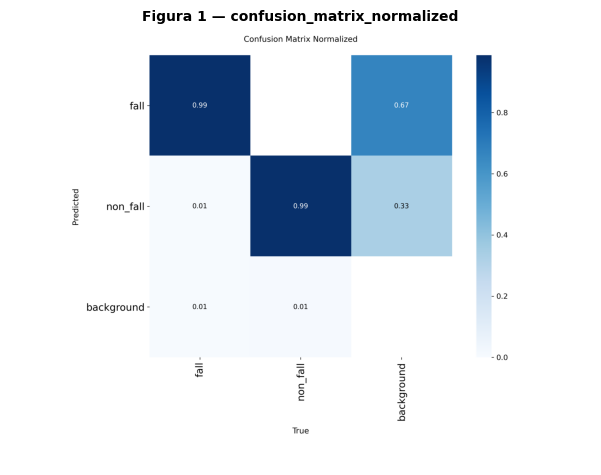


══════════════════════════════════════════════════════════════════════
  FIGURA 2  ·  confusion_matrix
══════════════════════════════════════════════════════════════════════
  📌 Utilidad : Matriz de confusión en TEST (conteos absolutos). Alternativa a la normalizada.
  📝 Pie      : «Figura __. Matriz de confusión (valores absolutos) del modelo de caídas sobre el conjunto de prueba. Fuente: elaboración propia.»
  📂 Archivo  : confusion_matrix.png  (PNG)
  📍 Ruta     : /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15_test_eval/confusion_matrix.png


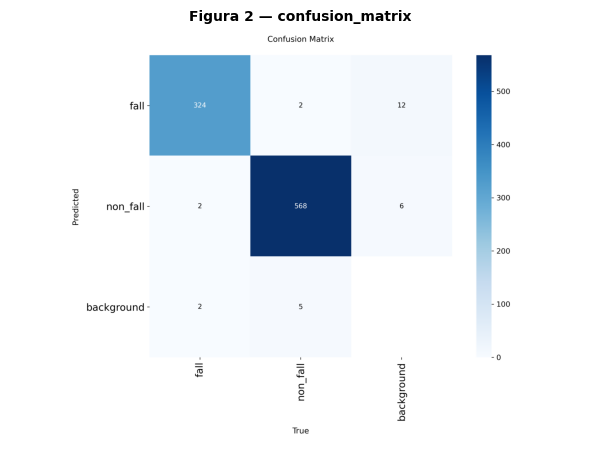


══════════════════════════════════════════════════════════════════════
  FIGURA 3  ·  BoxPR_curve
══════════════════════════════════════════════════════════════════════
  📌 Utilidad : Curva Precisión-Recall en TEST. Pertinente: la metodología prioriza el recall.
  📝 Pie      : «Figura __. Curva precisión-recall del modelo de detección de caídas sobre el conjunto de prueba. Fuente: elaboración propia.»
  📂 Archivo  : BoxPR_curve.png  (PNG)
  📍 Ruta     : /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15_test_eval/BoxPR_curve.png


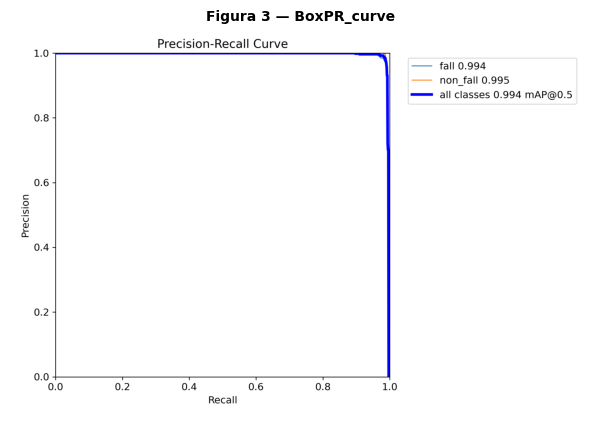


══════════════════════════════════════════════════════════════════════
  FIGURA 4  ·  BoxR_curve
══════════════════════════════════════════════════════════════════════
  📌 Utilidad : Curva de Recall vs confianza en TEST. Apoya el análisis de sensibilidad (métrica principal).
  📝 Pie      : «Figura __. Curva de recall en función del umbral de confianza, conjunto de prueba. Fuente: elaboración propia.»
  📂 Archivo  : BoxR_curve.png  (PNG)
  📍 Ruta     : /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15_test_eval/BoxR_curve.png


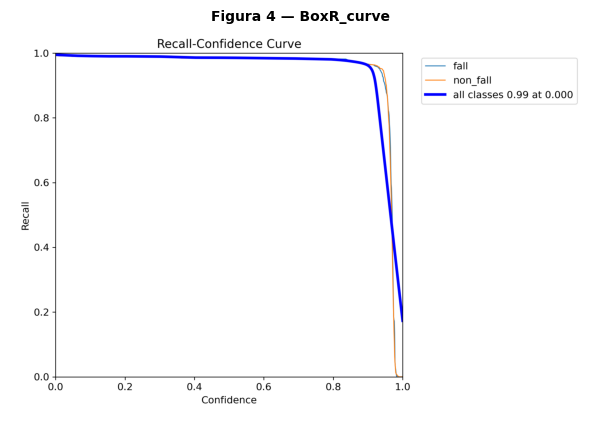


══════════════════════════════════════════════════════════════════════
  FIGURA 5  ·  BoxF1_curve
══════════════════════════════════════════════════════════════════════
  📌 Utilidad : Curva F1 vs confianza en TEST. Muestra el equilibrio precisión/recall y el umbral óptimo.
  📝 Pie      : «Figura __. Curva F1 en función del umbral de confianza, conjunto de prueba (caídas). Fuente: elaboración propia.»
  📂 Archivo  : BoxF1_curve.png  (PNG)
  📍 Ruta     : /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15_test_eval/BoxF1_curve.png


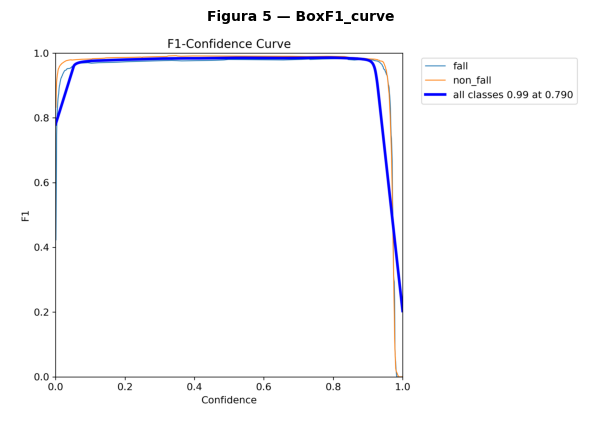


══════════════════════════════════════════════════════════════════════
  FIGURA 6  ·  fig_curvas_metricas_entrenamiento_completa
══════════════════════════════════════════════════════════════════════
  📌 Utilidad : Evolución de Precision/Recall/mAP por época. Evidencia que el modelo convergió.
  📝 Pie      : «Figura __. Evolución de las métricas durante el entrenamiento del modelo de caídas. Fuente: elaboración propia.»
  📂 Archivo  : fig_curvas_metricas_entrenamiento_completa.png  (PNG)
  📍 Ruta     : /content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_curvas_metricas_entrenamiento_completa.png


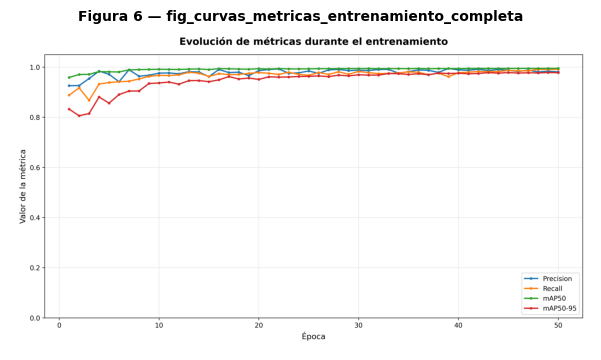


══════════════════════════════════════════════════════════════════════
  FIGURA 7  ·  fig_curvas_metricas_entrenamiento_zoom
══════════════════════════════════════════════════════════════════════
  📌 Utilidad : Versión ampliada (zoom) de las curvas de métricas.
  📝 Pie      : «Figura __. Detalle de la evolución de métricas en las épocas finales, modelo de caídas. Fuente: elaboración propia.»
  📂 Archivo  : fig_curvas_metricas_entrenamiento_zoom.png  (PNG)
  📍 Ruta     : /content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_curvas_metricas_entrenamiento_zoom.png


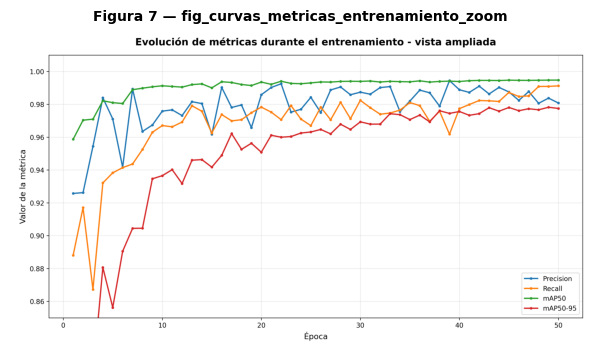


══════════════════════════════════════════════════════════════════════
  FIGURA 8  ·  fig_metricas_test_barras_agrupadas_corregida
══════════════════════════════════════════════════════════════════════
  📌 Utilidad : Barras de métricas finales en TEST por clase. Acompaña la tabla de resultados.
  📝 Pie      : «Figura __. Métricas de desempeño por clase en el conjunto de prueba, modelo de caídas. Fuente: elaboración propia.»
  📂 Archivo  : fig_metricas_test_barras_agrupadas_corregida.png  (PNG)
  📍 Ruta     : /content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_metricas_test_barras_agrupadas_corregida.png


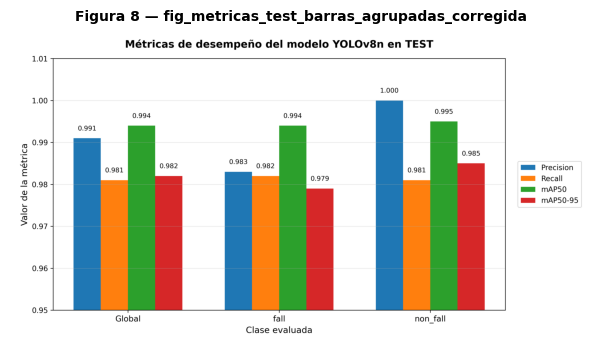


══════════════════════════════════════════════════════════════════════
  FIGURA 9  ·  fig_metricas_test_mapa_calor
══════════════════════════════════════════════════════════════════════
  📌 Utilidad : Mapa de calor de métricas en TEST por clase.
  📝 Pie      : «Figura __. Mapa de calor de las métricas por clase en el conjunto de prueba, modelo de caídas. Fuente: elaboración propia.»
  📂 Archivo  : fig_metricas_test_mapa_calor.png  (PNG)
  📍 Ruta     : /content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_metricas_test_mapa_calor.png


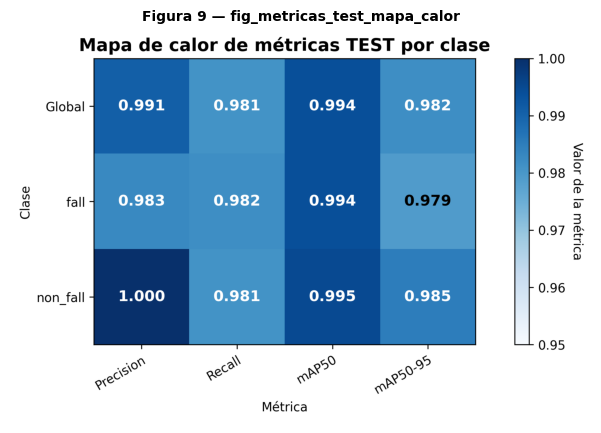


══════════════════════════════════════════════════════════════════════
  FIGURA 10  ·  fig_distribucion_clases_barras_absolutas
══════════════════════════════════════════════════════════════════════
  📌 Utilidad : Distribución de clases (conteo absoluto). Enlaza con la preparación de datos.
  📝 Pie      : «Figura __. Distribución de clases del dataset de caídas (valores absolutos). Fuente: elaboración propia.»
  📂 Archivo  : fig_distribucion_clases_barras_absolutas.png  (PNG)
  📍 Ruta     : /content/drive/MyDrive/TFM/figuras_resultados_yolo/fig_distribucion_clases_barras_absolutas.png


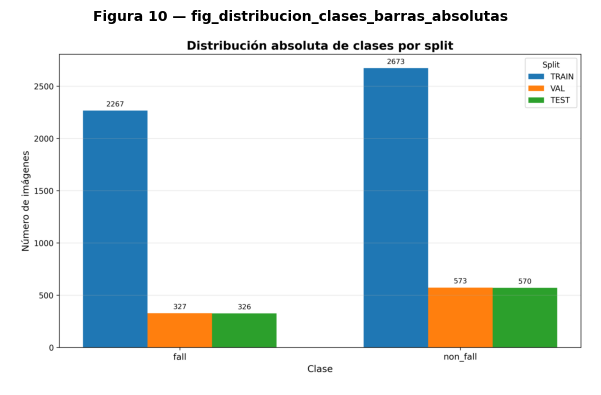


══════════════════════════════════════════════════════════════════════
  ✅ 10/10 figuras listas para el documento.
══════════════════════════════════════════════════════════════════════


In [4]:
# ============================================================
# 📋 CATÁLOGO VISUAL DE FIGURAS — CAÍDAS  (nombres corregidos)
# Las figuras de TEST están en _test_eval con nombres estándar
# de YOLO (sin prefijo "test_"). Busca PNG y PDF.
# Solo lectura: no descarga, no modifica, no toca Drive.
# ============================================================
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

TFM  = Path("/content/drive/MyDrive/TFM")
EVAL = TFM / "runs_yolo_caidas" / "baseline_yolov8n_clean_70_15_15_test_eval"
FIG  = TFM / "figuras_resultados_yolo"
PRED = TFM / "predicciones_yolo_caidas"

# (nombre_base, carpeta, para_qué, pie_sugerido)
CATALOGO = [
    ("confusion_matrix_normalized", EVAL,
     "Matriz de confusión en TEST (normalizada). Figura central: aciertos fall/non_fall.",
     "Matriz de confusión normalizada del modelo de detección de caídas sobre el conjunto de prueba."),
    ("confusion_matrix", EVAL,
     "Matriz de confusión en TEST (conteos absolutos). Alternativa a la normalizada.",
     "Matriz de confusión (valores absolutos) del modelo de caídas sobre el conjunto de prueba."),
    ("BoxPR_curve", EVAL,
     "Curva Precisión-Recall en TEST. Pertinente: la metodología prioriza el recall.",
     "Curva precisión-recall del modelo de detección de caídas sobre el conjunto de prueba."),
    ("BoxR_curve", EVAL,
     "Curva de Recall vs confianza en TEST. Apoya el análisis de sensibilidad (métrica principal).",
     "Curva de recall en función del umbral de confianza, conjunto de prueba."),
    ("BoxF1_curve", EVAL,
     "Curva F1 vs confianza en TEST. Muestra el equilibrio precisión/recall y el umbral óptimo.",
     "Curva F1 en función del umbral de confianza, conjunto de prueba (caídas)."),
    ("fig_curvas_metricas_entrenamiento_completa", FIG,
     "Evolución de Precision/Recall/mAP por época. Evidencia que el modelo convergió.",
     "Evolución de las métricas durante el entrenamiento del modelo de caídas."),
    ("fig_curvas_metricas_entrenamiento_zoom", FIG,
     "Versión ampliada (zoom) de las curvas de métricas.",
     "Detalle de la evolución de métricas en las épocas finales, modelo de caídas."),
    ("fig_metricas_test_barras_agrupadas_corregida", FIG,
     "Barras de métricas finales en TEST por clase. Acompaña la tabla de resultados.",
     "Métricas de desempeño por clase en el conjunto de prueba, modelo de caídas."),
    ("fig_metricas_test_mapa_calor", FIG,
     "Mapa de calor de métricas en TEST por clase.",
     "Mapa de calor de las métricas por clase en el conjunto de prueba, modelo de caídas."),
    ("fig_distribucion_clases_barras_absolutas", FIG,
     "Distribución de clases (conteo absoluto). Enlaza con la preparación de datos.",
     "Distribución de clases del dataset de caídas (valores absolutos)."),
]


def localizar(base, carpeta):
    for ext in (".png", ".pdf"):
        f = carpeta / f"{base}{ext}"
        if f.exists():
            return f
    return None


def render(ruta):
    if ruta.suffix.lower() == ".pdf":
        try:
            import fitz
        except ImportError:
            import subprocess, sys
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pymupdf"])
            import fitz
        import numpy as np
        doc = fitz.open(ruta)
        pix = doc[0].get_pixmap(dpi=110)
        img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
        doc.close()
        return img
    return mpimg.imread(ruta)


resueltas = [(b, localizar(b, c), pq, pie) for (b, c, pq, pie) in CATALOGO]
ok = sum(1 for _, r, _, _ in resueltas if r)

print("╔" + "═"*68 + "╗")
print("║" + "  📋 CATÁLOGO VISUAL DE FIGURAS — CAÍDAS".ljust(68) + "║")
print("╚" + "═"*68 + "╝")
print(f"\nÍNDICE  ({ok}/{len(CATALOGO)} disponibles):")
for n, (base, ruta, _, _) in enumerate(resueltas, 1):
    print(f"  {n}. [{'✅' if ruta else '❌'}] {base}{('  · ' + ruta.suffix[1:].upper()) if ruta else ''}")

for n, (base, ruta, para_que, pie) in enumerate(resueltas, 1):
    print("\n" + "═"*70)
    print(f"  FIGURA {n}  ·  {base}")
    print("═"*70)
    print(f"  📌 Utilidad : {para_que}")
    print(f"  📝 Pie      : «Figura __. {pie} Fuente: elaboración propia.»")
    if ruta:
        print(f"  📂 Archivo  : {ruta.name}  ({ruta.suffix[1:].upper()})")
        print(f"  📍 Ruta     : {ruta}")
        try:
            img = render(ruta)
            plt.figure(figsize=(7.5, 7.5)); plt.imshow(img); plt.axis("off")
            plt.title(f"Figura {n} — {base}", fontsize=10, fontweight="bold")
            plt.show()
        except Exception as e:
            print(f"  ⚠️ No se pudo mostrar: {e}")
    else:
        print("  ❌ No encontrada.")

print("\n" + "═"*70)
print(f"  ✅ {ok}/{len(CATALOGO)} figuras listas para el documento.")
print("═"*70)